In [3]:
import os
from getpass import getpass
from huggingface_hub import login

if not os.getenv("HF_TOKEN"):
    os.environ["HF_TOKEN"] = getpass("Enter your HF token: ")

login(token=os.environ["HF_TOKEN"])


Enter your HF token: ··········


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# ORPO Experiment Notebook (CS555)

> **This notebook is for ORPO only.** Prerequisite cells (baseline, DPO, ablations) are included with **preserved outputs** so the notebook runs standalone after a Colab restart. The main pipeline (DPO, IPO, P1/P2/P3) lives in `baseline_inference.ipynb`.

## How to use this file
| Goal | What to do |
|------|------------|
| **Review ORPO results** | Scroll to **Phase C** and **Phase D** — outputs are saved |
| **Re-run ORPO from scratch** | Fresh Colab GPU → run all `[PREREQ]` cells → P0 → P1.1 → C1–C4 |
| **Understand prior pipeline** | Read `[REFERENCE]` sections — do not re-run unless needed |

## Cell status legend
| Tag | Meaning |
|-----|---------|
| **`[PREREQ]`** | Required after restart (before ORPO) |
| **`[REFERENCE — results preserved]`** | Shared pipeline from main notebook — outputs kept for context |
| **`[ORPO CORE — completed]`** | ORPO train + eval — **primary contribution of this file** |
| **`[RESULTS — completed]`** | Final tables and figures |
| **`[OPTIONAL]`** | Wilcoxon tests (needs CSVs from main notebook Phase B) |

## ORPO run order (fresh session)
```
PREREQ: 0 → 1 → Restart → 1b → 2 → 14 → 19 → 20 → P0 → P1.1
ORPO:   C1 → C2 (smoke) → C3 (train ~90 min) → C4 (eval n=1000)
Report: Final table → F2 → F3
```

## Metrics (same as main notebook)
Judge-free ranking on chosen vs rejected — **per-token PrefAcc** is the primary metric.

In [4]:
# [PREREQ] 0) Setup — run after every Colab restart
import os
import json
import random
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/CS555_DPO_Project"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

torch: 2.12.0+cu130
cuda available: True
device: cuda


In [11]:
# [PREREQ] 1) Install pinned libs — run after EVERY restart, then Runtime -> Restart session
# Colab often pre-installs transformers 5.x (no is_flax_available). Uninstall + pin below.
# ORPO needs trl>=0.13 + transformers 4.46.x. Restart BEFORE running 1b.
!pip uninstall -y transformers trl peft accelerate 2>/dev/null | tail -5 || true
!pip install -q --no-cache-dir --force-reinstall \
    "transformers==4.46.3" \
    "trl==0.13.0" \
    "peft==0.13.2" \
    "accelerate==0.34.2" \
    "torchao>=0.16.0" \
    "datasets" "sentencepiece"
!pip show transformers trl peft | grep -E "^Name:|^Version:"


Uninstalling peft-0.13.2:
  Successfully uninstalled peft-0.13.2
Found existing installation: accelerate 0.34.2
Uninstalling accelerate-0.34.2:
  Successfully uninstalled accelerate-0.34.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 51.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 250.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 294.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 324.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 270.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 322.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 165.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.4/293.4 kB 345.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 373.9 MB/s eta 0:00:00
  

In [2]:
import transformers, trl
print("transformers", transformers.__version__)
print("trl", trl.__version__)
#If transformers is still 5.x, rerun PREREQ 1 and restart again.
#If versions look right but import still fails, run PREREQ 1 once more and restart.

transformers 4.46.3
trl 0.13.0


In [1]:
try:
    import torchvision
    print("torchvision", torchvision.__version__)
except Exception as e:
    print("WARNING: torchvision broken — re-run PREREQ 1 Step B + Restart. Error:", e)

torchvision 0.27.0+cu130


In [5]:
!pip uninstall -y torchvision
!pip install -q --upgrade torch torchvision torchaudio
!pip install --upgrade torch torchvision torchaudio
import torch
print("torch before fix:", torch.__version__)
!pip install -q --upgrade torch torchvision torchaudio
!pip show transformers trl peft torch torchvision | grep -E "^Name:|^Version:"
try:
    import torchvision
    print("torchvision", torchvision.__version__)
except Exception as e:
    print("WARNING: needed version: torchvision 0.27.0+cu130- torchvision broken — re-run PREREQ 1 Step B + Restart. Error:", e)

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 125.6 MB/s eta 0:00:00
torch before fix: 2.12.0+cu130
Name: transformers
Version: 4.46.3
Name: trl
Version: 0.13.0
Name: peft
Version: 0.13.2
Name: torch
Version: 2.12.0
Name: torchvision
Version: 0.27.0


In [5]:
# [PREREQ] 1b) Verify ORPOTrainer (run AFTER restart, before Phase C)
import transformers
import trl as _trl
from packaging import version

print("transformers", transformers.__version__)
print("trl", _trl.__version__)

if version.parse(transformers.__version__) >= version.parse("5.0.0"):
    raise RuntimeError(
        f"transformers {transformers.__version__} is still loaded (need 4.46.x). "
        "Run [PREREQ] 1), then Runtime -> Restart session, then this cell."
    )

from trl import ORPOTrainer, ORPOConfig

if version.parse(_trl.__version__) < version.parse("0.13.0"):
    raise RuntimeError(
        f"Need trl>=0.13 for ORPO (have {_trl.__version__}). "
        "Re-run [PREREQ] 1), Restart runtime, then this cell."
    )
print("ORPOTrainer OK | ORPOConfig.beta = ORPO λ (not DPO KL-β)")


transformers 4.46.3
trl 0.13.0


W0607 14:22:35.234000 4258 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


ORPOTrainer OK | ORPOConfig.beta = ORPO λ (not DPO KL-β)


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# [PREREQ] 2) Config — run after restart
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"   # fallback: Qwen/Qwen2.5-1.5B-Instruct
DATASET_NAME = "trl-lib/ultrafeedback_binarized"
SPLIT = "test"
MAX_EVAL_SAMPLES = 200

In [ ]:
# [SKIP - done] 3) Load dataset + inspect schema
ds = load_dataset(DATASET_NAME)
print(ds)
print("columns:", ds[SPLIT].column_names)
print("example keys:", ds[SPLIT][0].keys())
print(ds[SPLIT][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/643 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/131M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.14M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/62135 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 62135
    })
    test: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 1000
    })
})
columns: ['chosen', 'rejected', 'score_chosen', 'score_rejected']
example keys: dict_keys(['chosen', 'rejected', 'score_chosen', 'score_rejected'])
{'chosen': [{'content': 'As an HR manager, you want to test a potential employee\'s ability to solve puzzles to determine their suitability for a job. Write a Python script that generates a list of questions that require logical reasoning to answer. Your list should include questions related to mathematical puzzles, language puzzles, logic puzzles, lateral thinking puzzles, and pattern recognition puzzles. Use the following code as a starting point:\nquestions = {\n    "Mathematical puzzles": ["If the value of x+y = 20 and x-y = 10, what is the value of x and y?", "If a pizz

In [ ]:
# [SKIP - done] 4) Build eval subset
eval_ds = ds[SPLIT].shuffle(seed=SEED).select(range(min(MAX_EVAL_SAMPLES, len(ds[SPLIT]))))
print("eval size:", len(eval_ds))

# [SKIP - done] 5) Load model (base model for baseline eval)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()

eval size: 200


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [8]:
# [SKIP - done] 6) Utilities: extract triplets and compute conditional log-prob

def extract_triplet(ex):
    chosen_user = [m["content"] for m in ex["chosen"] if m.get("role") == "user"]
    chosen_asst = [m["content"] for m in ex["chosen"] if m.get("role") == "assistant"]
    rejected_asst = [m["content"] for m in ex["rejected"] if m.get("role") == "assistant"]

    if not chosen_user or not chosen_asst or not rejected_asst:
        return None

    prompt = chosen_user[0]
    chosen_answer = chosen_asst[-1]
    rejected_answer = rejected_asst[-1]
    return prompt, chosen_answer, rejected_answer


def _chat_to_text(messages, add_generation_prompt=False):
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=add_generation_prompt,
    )


def _text_to_input_ids(text):
    enc = tokenizer(text, return_tensors="pt", add_special_tokens=False)
    return enc["input_ids"].to(model.device)


@torch.no_grad()
def conditional_logprob(prompt_text: str, answer_text: str):
    """Return (sum_logprob, num_answer_tokens) for logP(answer|prompt).

    Note: We sum log-prob of tokens in the assistant answer segment
    (as determined by the prompt prefix token length).
    """
    prompt_chat = _chat_to_text(
        [{"role": "user", "content": prompt_text}],
        add_generation_prompt=True,
    )
    full_chat = _chat_to_text(
        [
            {"role": "user", "content": prompt_text},
            {"role": "assistant", "content": answer_text},
        ],
        add_generation_prompt=False,
    )

    prompt_ids = _text_to_input_ids(prompt_chat)
    full_ids = _text_to_input_ids(full_chat)

    outputs = model(input_ids=full_ids)
    logits = outputs.logits[:, :-1, :]
    labels = full_ids[:, 1:]

    # token_lp[j] is logP(full_ids[:, j+1] | full_ids[:, :j+1])
    ans_start = max(prompt_ids.shape[1] - 1, 0)
    log_probs = torch.log_softmax(logits, dim=-1)
    token_lp = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)

    ans_token_lp = token_lp[:, ans_start:]
    sum_logprob = ans_token_lp.sum().item()
    num_tokens = int(ans_token_lp.shape[1])
    return sum_logprob, num_tokens

In [ ]:
# [SKIP - done] 7) Compute ranking metrics (baseline)
margins_sum = []
margins_mean = []
valid = 0

chosen_ns = []
rejected_ns = []

for ex in eval_ds:
    triplet = extract_triplet(ex)
    if triplet is None:
        continue

    prompt, chosen, rejected = triplet

    res_chosen = conditional_logprob(prompt, chosen)
    res_rejected = conditional_logprob(prompt, rejected)

    # Compatibility: depending on notebook execution order, conditional_logprob
    # may return either float (sum logP) or (sum_logprob, num_tokens).
    if isinstance(res_chosen, tuple):
        lp_chosen_sum, lp_chosen_n = res_chosen
    else:
        lp_chosen_sum, lp_chosen_n = float(res_chosen), 1

    if isinstance(res_rejected, tuple):
        lp_rejected_sum, lp_rejected_n = res_rejected
    else:
        lp_rejected_sum, lp_rejected_n = float(res_rejected), 1

    margins_sum.append(lp_chosen_sum - lp_rejected_sum)
    margins_mean.append((lp_chosen_sum / max(lp_chosen_n, 1)) - (lp_rejected_sum / max(lp_rejected_n, 1)))

    chosen_ns.append(lp_chosen_n)
    rejected_ns.append(lp_rejected_n)

    valid += 1

pref_acc = float(np.mean([m > 0 for m in margins_sum])) if margins_sum else 0.0
mean_margin = float(np.mean(margins_sum)) if margins_sum else 0.0

pref_acc_mean = float(np.mean([m > 0 for m in margins_mean])) if margins_mean else 0.0
mean_margin_mean = float(np.mean(margins_mean)) if margins_mean else 0.0

avg_chosen_tokens = float(np.mean(chosen_ns)) if chosen_ns else 0.0
avg_rejected_tokens = float(np.mean(rejected_ns)) if rejected_ns else 0.0
avg_delta_tokens = avg_chosen_tokens - avg_rejected_tokens

print(f"Valid examples: {valid}")
print(f"Preference Accuracy (sum logP): {pref_acc:.4f}")
print(f"Mean Log-Prob Margin (sum): {mean_margin:.4f}")
print(f"Preference Accuracy (mean logP/token): {pref_acc_mean:.4f}")
print(f"Mean Log-Prob Margin (mean): {mean_margin_mean:.4f}")
print(f"Avg chosen answer tokens: {avg_chosen_tokens:.2f}")
print(f"Avg rejected answer tokens: {avg_rejected_tokens:.2f}")
print(f"Avg (chosen - rejected) tokens: {avg_delta_tokens:.2f}")

Valid examples: 200
Preference Accuracy (sum logP): 0.4400
Mean Log-Prob Margin (sum): -51.2133
Preference Accuracy (mean logP/token): 0.6100
Mean Log-Prob Margin (mean): 0.2992
Avg chosen answer tokens: 265.12
Avg rejected answer tokens: 218.78
Avg (chosen - rejected) tokens: 46.35


In [ ]:
# 8) Save metrics artifact
os.makedirs("outputs", exist_ok=True)

metrics = {
    "model": MODEL_NAME,
    "dataset": DATASET_NAME,
    "split": SPLIT,
    "n_requested": MAX_EVAL_SAMPLES,
    "n_valid": valid,
    "preference_accuracy": pref_acc,
    "mean_logprob_margin": mean_margin,
    "preference_accuracy_mean": pref_acc_mean,
    "mean_logprob_margin_mean": mean_margin_mean,
    "avg_chosen_answer_tokens": avg_chosen_tokens,
    "avg_rejected_answer_tokens": avg_rejected_tokens,
    "avg_chosen_minus_rejected_tokens": avg_delta_tokens,
    "seed": SEED,
}

with open("outputs/baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved: outputs/baseline_metrics.json")
print(metrics)

Saved: outputs/baseline_metrics.json
{'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'dataset': 'trl-lib/ultrafeedback_binarized', 'split': 'test', 'n_requested': 200, 'n_valid': 200, 'preference_accuracy': 0.44, 'mean_logprob_margin': -51.213272705078126, 'preference_accuracy_mean': 0.61, 'mean_logprob_margin_mean': 0.29916862150109286, 'avg_chosen_answer_tokens': 265.125, 'avg_rejected_answer_tokens': 218.775, 'avg_chosen_minus_rejected_tokens': 46.349999999999994, 'seed': 42}


In [ ]:
# 10) Save per-example margins to CSV (for later comparison with DPO model)
import csv

per_example_path = "outputs/baseline_per_example.csv"
os.makedirs("outputs", exist_ok=True)

with open(per_example_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "idx",
        "chosen_tokens",
        "rejected_tokens",
        "margin_sum",
        "margin_mean_per_token",
    ])
    for i, (m_sum, m_mean, n_c, n_r) in enumerate(
        zip(margins_sum, margins_mean, chosen_ns, rejected_ns)
    ):
        writer.writerow([i, n_c, n_r, m_sum, m_mean])

print(f"Saved: {per_example_path}")
print("Rows:", len(margins_sum))

Saved: outputs/baseline_per_example.csv
Rows: 200


In [ ]:
# 11) Persist outputs to Google Drive (Colab only)
# This copies outputs/* into a project folder on your Drive so they
# don't disappear when the runtime is reset.
import shutil

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/CS555_DPO_Project"

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    target_dir = os.path.join(DRIVE_PROJECT_DIR, "outputs")
    os.makedirs(target_dir, exist_ok=True)

    for fname in os.listdir("outputs"):
        src = os.path.join("outputs", fname)
        dst = os.path.join(target_dir, fname)
        shutil.copy2(src, dst)

    print("Copied outputs to:", target_dir)
    print("Files:", os.listdir(target_dir))
except Exception as e:
    print("Drive persistence skipped:", e)

Mounted at /content/drive
Copied outputs to: /content/drive/MyDrive/CS555_DPO_Project/outputs
Files: ['baseline_metrics.json', 'baseline_per_example.csv']


In [ ]:
# 12) Download outputs to local machine (Colab only)
# Use this if you also want a local copy in your Downloads folder.
try:
    from google.colab import files
    for fname in os.listdir("outputs"):
        files.download(os.path.join("outputs", fname))
        print("done")
except Exception as e:
    print("Local download skipped:", e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

done


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

done


In [19]:
# [RUN ONCE - SKIP if splits on Drive] 13) Save deterministic dataset splits to Google Drive
# Creates fixed train / validation / eval-test subsets so baseline and DPO
# are evaluated on the exact same examples in any future Colab session.
from datasets import load_dataset, DatasetDict

DRIVE_DATA_DIR = "/content/drive/MyDrive/CS555_DPO_Project/data"

DPO_TRAIN_SIZE = 20000
VAL_SIZE = 500
EVAL_TEST_SIZE = MAX_EVAL_SAMPLES

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    os.makedirs(DRIVE_DATA_DIR, exist_ok=True)

    raw = load_dataset(DATASET_NAME)

    train_shuffled = raw["train"].shuffle(seed=SEED)
    test_shuffled = raw["test"].shuffle(seed=SEED)

    dpo_train = train_shuffled.select(range(min(DPO_TRAIN_SIZE, len(train_shuffled))))
    val_set = train_shuffled.select(
        range(
            min(DPO_TRAIN_SIZE, len(train_shuffled)),
            min(DPO_TRAIN_SIZE + VAL_SIZE, len(train_shuffled)),
        )
    )
    eval_test = test_shuffled.select(range(min(EVAL_TEST_SIZE, len(test_shuffled))))

    splits = DatasetDict({
        "dpo_train": dpo_train,
        "val": val_set,
        "eval_test": eval_test,
    })

    save_path = os.path.join(DRIVE_DATA_DIR, "splits_seed42")
    splits.save_to_disk(save_path)

    print("Saved splits to:", save_path)
    print(splits)
except Exception as e:
    print("Drive split save skipped:", e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving the dataset (0/1 shards):   0%|          | 0/20000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saved splits to: /content/drive/MyDrive/CS555_DPO_Project/data/splits_seed42
DatasetDict({
    dpo_train: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 20000
    })
    val: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 500
    })
    eval_test: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 200
    })
})


In [ ]:
# [PREREQ] 14) Load deterministic dataset splits from Drive
# If Drive is mounted and splits exist, this is the canonical loader.
# Falls back to HuggingFace + seed if Drive is not available.
from datasets import load_from_disk

DRIVE_DATA_DIR = "/content/drive/MyDrive/CS555_DPO_Project/data"
DPO_TRAIN_SIZE = 20000
VAL_SIZE = 500
EVAL_TEST_SIZE = MAX_EVAL_SAMPLES
splits_path = os.path.join(DRIVE_DATA_DIR, "splits_seed42")

try:
    if os.path.exists(splits_path):
        splits = load_from_disk(splits_path)
        dpo_train = splits["dpo_train"]
        val_set = splits["val"]
        eval_test = splits["eval_test"]
        print("Loaded splits from Drive:", splits_path)
    else:
        raise FileNotFoundError(splits_path)
except Exception as e:
    print("Falling back to HF + seed:", e)
    raw = load_dataset(DATASET_NAME)
    train_shuffled = raw["train"].shuffle(seed=SEED)
    test_shuffled = raw["test"].shuffle(seed=SEED)
    dpo_train = train_shuffled.select(range(min(DPO_TRAIN_SIZE, len(train_shuffled))))
    val_set = train_shuffled.select(
        range(
            min(DPO_TRAIN_SIZE, len(train_shuffled)),
            min(DPO_TRAIN_SIZE + VAL_SIZE, len(train_shuffled)),
        )
    )
    eval_test = test_shuffled.select(range(min(EVAL_TEST_SIZE, len(test_shuffled))))

print("dpo_train size:", len(dpo_train))
print("val size:", len(val_set))
print("eval_test size:", len(eval_test))

# eval_ds (used by metric cells) is now the canonical eval_test from Drive.
eval_ds = eval_test

Falling back to HF + seed: /content/drive/MyDrive/CS555_DPO_Project/data/splits_seed42
dpo_train size: 20000
val size: 500
eval_test size: 200


---
## Part 1 — Shared prerequisites (reference)

Cells **3–57** reproduce the setup, baseline, prompt engineering, DPO, and Ablation 1 pipeline from the main notebook. **Outputs are preserved** for reproducibility context. Skip when reviewing ORPO only.

In [ ]:
# 9) (Optional) Inspect first few margins for sanity check
print("First 5 margins:", margins[:5])
print("Positive margin ratio:", np.mean([m > 0 for m in margins]) if margins else 0.0)

First 5 margins: [-153.5, 10.125, 46.1875, 111.0, 12.48046875]
Positive margin ratio: 0.44


In [ ]:
import os
print(os.listdir())
print(os.listdir("outputs"))

['.config', 'outputs', 'sample_data']
['baseline_metrics.json']


In [ ]:
margins_flip = [-m for m in margins]
pref_acc_flip = float(np.mean([m > 0 for m in margins_flip])) if margins_flip else 0.0
mean_margin_flip = float(np.mean(margins_flip)) if margins_flip else 0.0
print(pref_acc_flip, mean_margin_flip)

0.555 51.213272705078126


In [ ]:
print(type(tokenizer.apply_chat_template([{"role":"user","content":"hi"}], tokenize=False, add_generation_prompt=True)))
print(tokenizer.apply_chat_template([{"role":"user","content":"hi"}], tokenize=False, add_generation_prompt=True))

<class 'str'>
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
hi<|im_end|>
<|im_start|>assistant



## Prompt Engineering Baselines (no DPO) — **[REFERENCE — results preserved]**

We evaluate the SAME base model under two different prompting strategies:

- **Simple** prompt: a minimal "You are a helpful assistant." system message.
- **Structured** prompt: a detailed system message specifying format, factuality, and concision constraints.

For each, we recompute:
- Preference Accuracy (sum logP)
- Mean Log-Prob Margin (sum)
- Preference Accuracy (mean logP/token)
- Mean Log-Prob Margin (mean)
- Avg chosen / rejected answer tokens

This isolates the effect of prompt engineering from any fine-tuning.

In [ ]:
# 15) Prompt templates + flexible scorer (system_prompt aware)

# SIMPLE: minimal, task-only system prompt (no quality cues).
# This is intentionally different from Qwen's default "helpful assistant"
# message so the comparison is meaningful.
SIMPLE_SYSTEM_PROMPT = "Answer the user's question."

# STRUCTURED: explicit quality criteria describing what a better answer
# looks like (helpful, accurate, concise, well-structured, on-topic).
STRUCTURED_SYSTEM_PROMPT = (
    "You are a helpful, accurate, and concise assistant.\n"
    "A high-quality answer is:\n"
    "- Helpful: directly addresses the user's instruction.\n"
    "- Honest and factual: never invent facts; if uncertain, say so.\n"
    "- Faithful to the instruction: follows constraints, format, and scope.\n"
    "- Clear: structured into short paragraphs or bullet points when useful.\n"
    "- Concise: avoids preamble, repetition, and filler.\n"
    "- Complete: stops once the user's request is fully satisfied.\n"
    "Apply these criteria when producing your response."
)


def _build_messages(system_prompt, user_prompt, assistant_answer=None):
    msgs = []
    if system_prompt is not None:
        msgs.append({"role": "system", "content": system_prompt})
    msgs.append({"role": "user", "content": user_prompt})
    if assistant_answer is not None:
        msgs.append({"role": "assistant", "content": assistant_answer})
    return msgs


@torch.no_grad()
def conditional_logprob_with_system(prompt_text, answer_text, system_prompt):
    prompt_chat = _chat_to_text(
        _build_messages(system_prompt, prompt_text),
        add_generation_prompt=True,
    )
    full_chat = _chat_to_text(
        _build_messages(system_prompt, prompt_text, answer_text),
        add_generation_prompt=False,
    )

    prompt_ids = _text_to_input_ids(prompt_chat)
    full_ids = _text_to_input_ids(full_chat)

    outputs = model(input_ids=full_ids)
    logits = outputs.logits[:, :-1, :]
    labels = full_ids[:, 1:]

    ans_start = max(prompt_ids.shape[1] - 1, 0)
    log_probs = torch.log_softmax(logits, dim=-1)
    token_lp = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)

    ans_token_lp = token_lp[:, ans_start:]
    return ans_token_lp.sum().item(), int(ans_token_lp.shape[1])


def evaluate_prompt(eval_dataset, system_prompt, label):
    margins_sum_local = []
    margins_mean_local = []
    chosen_ns_local = []
    rejected_ns_local = []
    valid_local = 0

    for ex in eval_dataset:
        triplet = extract_triplet(ex)
        if triplet is None:
            continue
        prompt, chosen, rejected = triplet

        lp_c_sum, lp_c_n = conditional_logprob_with_system(prompt, chosen, system_prompt)
        lp_r_sum, lp_r_n = conditional_logprob_with_system(prompt, rejected, system_prompt)

        margins_sum_local.append(lp_c_sum - lp_r_sum)
        margins_mean_local.append((lp_c_sum / max(lp_c_n, 1)) - (lp_r_sum / max(lp_r_n, 1)))
        chosen_ns_local.append(lp_c_n)
        rejected_ns_local.append(lp_r_n)
        valid_local += 1

    pref_acc_local = float(np.mean([m > 0 for m in margins_sum_local])) if margins_sum_local else 0.0
    mean_margin_local = float(np.mean(margins_sum_local)) if margins_sum_local else 0.0
    pref_acc_mean_local = float(np.mean([m > 0 for m in margins_mean_local])) if margins_mean_local else 0.0
    mean_margin_mean_local = float(np.mean(margins_mean_local)) if margins_mean_local else 0.0
    avg_c = float(np.mean(chosen_ns_local)) if chosen_ns_local else 0.0
    avg_r = float(np.mean(rejected_ns_local)) if rejected_ns_local else 0.0

    print(f"--- {label} ---")
    print(f"Valid: {valid_local}")
    print(f"Pref Acc (sum logP):           {pref_acc_local:.4f}")
    print(f"Mean Margin (sum):             {mean_margin_local:.4f}")
    print(f"Pref Acc (mean logP/token):    {pref_acc_mean_local:.4f}")
    print(f"Mean Margin (mean):            {mean_margin_mean_local:.4f}")
    print(f"Avg chosen tokens:             {avg_c:.2f}")
    print(f"Avg rejected tokens:           {avg_r:.2f}")
    print(f"Avg (chosen - rejected):       {avg_c - avg_r:.2f}")
    print()

    return {
        "label": label,
        "system_prompt": system_prompt,
        "n_valid": valid_local,
        "preference_accuracy": pref_acc_local,
        "mean_logprob_margin": mean_margin_local,
        "preference_accuracy_mean": pref_acc_mean_local,
        "mean_logprob_margin_mean": mean_margin_mean_local,
        "avg_chosen_answer_tokens": avg_c,
        "avg_rejected_answer_tokens": avg_r,
        "avg_chosen_minus_rejected_tokens": avg_c - avg_r,
        "margins_sum": margins_sum_local,
        "margins_mean": margins_mean_local,
        "chosen_ns": chosen_ns_local,
        "rejected_ns": rejected_ns_local,
    }

In [ ]:
# 16) Run prompt-engineering baselines on the same eval_test set
results_simple = evaluate_prompt(eval_ds, SIMPLE_SYSTEM_PROMPT, "Simple prompt")
results_structured = evaluate_prompt(eval_ds, STRUCTURED_SYSTEM_PROMPT, "Structured prompt")

--- Simple prompt ---
Valid: 200
Pref Acc (sum logP):           0.4400
Mean Margin (sum):             -51.2912
Pref Acc (mean logP/token):    0.5950
Mean Margin (mean):            0.2874
Avg chosen tokens:             265.12
Avg rejected tokens:           218.78
Avg (chosen - rejected):       46.35

--- Structured prompt ---
Valid: 200
Pref Acc (sum logP):           0.4450
Mean Margin (sum):             -51.0683
Pref Acc (mean logP/token):    0.5900
Mean Margin (mean):            0.3315
Avg chosen tokens:             265.12
Avg rejected tokens:           218.78
Avg (chosen - rejected):       46.35



In [ ]:
# 17) Save prompt-engineering metrics + per-example CSVs

import csv

def _save_results(results, name):
    os.makedirs("outputs", exist_ok=True)

    summary_path = f"outputs/baseline_metrics_{name}.json"
    csv_path = f"outputs/baseline_per_example_{name}.csv"

    skip = {"margins_sum", "margins_mean", "chosen_ns", "rejected_ns", "few_shot_pairs"}
    summary = {k: v for k, v in results.items() if k not in skip}
    summary["model"] = MODEL_NAME
    summary["dataset"] = DATASET_NAME
    summary["split"] = SPLIT
    summary["seed"] = SEED

    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["idx", "chosen_tokens", "rejected_tokens", "margin_sum", "margin_mean_per_token"])
        for i, (ms, mm, nc, nr) in enumerate(
            zip(results["margins_sum"], results["margins_mean"], results["chosen_ns"], results["rejected_ns"])
        ):
            writer.writerow([i, nc, nr, ms, mm])

    print(f"Saved: {summary_path}")
    print(f"Saved: {csv_path}")


_save_results(results_simple, "simple")
_save_results(results_structured, "structured")

NameError: name 'results_simple' is not defined

In [ ]:
# 18) (Optional) Persist new prompt-engineering outputs to Drive
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    target_dir = os.path.join(DRIVE_PROJECT_DIR, "outputs")
    os.makedirs(target_dir, exist_ok=True)

    for fname in os.listdir("outputs"):
        src = os.path.join("outputs", fname)
        dst = os.path.join(target_dir, fname)
        shutil.copy2(src, dst)

    print("Synced outputs to:", target_dir)
    print("Files:", sorted(os.listdir(target_dir)))
except Exception as e:
    print("Drive sync skipped:", e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Synced outputs to: /content/drive/MyDrive/CS555_DPO_Project/outputs
Files: ['baseline_metrics.json', 'baseline_metrics_simple.json', 'baseline_metrics_structured.json', 'baseline_per_example.csv', 'baseline_per_example_simple.csv', 'baseline_per_example_structured.csv']


## Prompt Engineering Techniques — **[REFERENCE — results preserved]**

We compare additional prompt-engineering strategies on the SAME
eval_test set, using the SAME base model (no fine-tuning):

- **Few-shot (2-shot)**: 2 high-quality Q/A demonstrations precede
  the user prompt, shifting the distribution toward similar answers.
- **Chain-of-Thought (CoT)**: system prompt encourages step-by-step
  reasoning. Note: CoT is a *generation* technique; for ranking
  (logP scoring) it may not help, since chosen/rejected answers in
  UltraFeedback are not in step-by-step format. Reported for
  completeness.
- **Expert + Rubric**: combines an expert persona with the quality
  criteria from the structured prompt.

All variants are scored with the same `logP(answer | prompt+context)`
procedure used for `simple` and `structured`.

In [9]:
# [PREREQ for eval] 19) Few-shot-aware message builder + scorer

def _build_messages_v2(system_prompt, user_prompt, assistant_answer=None, few_shot_pairs=None):
    msgs = []
    if system_prompt is not None:
        msgs.append({"role": "system", "content": system_prompt})
    if few_shot_pairs:
        for ex_q, ex_a in few_shot_pairs:
            msgs.append({"role": "user", "content": ex_q})
            msgs.append({"role": "assistant", "content": ex_a})
    msgs.append({"role": "user", "content": user_prompt})
    if assistant_answer is not None:
        msgs.append({"role": "assistant", "content": assistant_answer})
    return msgs


@torch.no_grad()
def conditional_logprob_v2(prompt_text, answer_text, system_prompt, few_shot_pairs=None):
    prompt_chat = _chat_to_text(
        _build_messages_v2(system_prompt, prompt_text, few_shot_pairs=few_shot_pairs),
        add_generation_prompt=True,
    )
    full_chat = _chat_to_text(
        _build_messages_v2(system_prompt, prompt_text, answer_text, few_shot_pairs=few_shot_pairs),
        add_generation_prompt=False,
    )

    prompt_ids = _text_to_input_ids(prompt_chat)
    full_ids = _text_to_input_ids(full_chat)

    outputs = model(input_ids=full_ids)
    logits = outputs.logits[:, :-1, :]
    labels = full_ids[:, 1:]

    ans_start = max(prompt_ids.shape[1] - 1, 0)
    log_probs = torch.log_softmax(logits, dim=-1)
    token_lp = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)

    ans_token_lp = token_lp[:, ans_start:]
    return ans_token_lp.sum().item(), int(ans_token_lp.shape[1])


def evaluate_prompt_v2(eval_dataset, system_prompt, label, few_shot_pairs=None):
    margins_sum_local = []
    margins_mean_local = []
    chosen_ns_local = []
    rejected_ns_local = []
    valid_local = 0

    for ex in eval_dataset:
        triplet = extract_triplet(ex)
        if triplet is None:
            continue
        prompt, chosen, rejected = triplet

        lp_c_sum, lp_c_n = conditional_logprob_v2(prompt, chosen, system_prompt, few_shot_pairs)
        lp_r_sum, lp_r_n = conditional_logprob_v2(prompt, rejected, system_prompt, few_shot_pairs)

        margins_sum_local.append(lp_c_sum - lp_r_sum)
        margins_mean_local.append((lp_c_sum / max(lp_c_n, 1)) - (lp_r_sum / max(lp_r_n, 1)))
        chosen_ns_local.append(lp_c_n)
        rejected_ns_local.append(lp_r_n)
        valid_local += 1

    pref_acc_local = float(np.mean([m > 0 for m in margins_sum_local])) if margins_sum_local else 0.0
    mean_margin_local = float(np.mean(margins_sum_local)) if margins_sum_local else 0.0
    pref_acc_mean_local = float(np.mean([m > 0 for m in margins_mean_local])) if margins_mean_local else 0.0
    mean_margin_mean_local = float(np.mean(margins_mean_local)) if margins_mean_local else 0.0
    avg_c = float(np.mean(chosen_ns_local)) if chosen_ns_local else 0.0
    avg_r = float(np.mean(rejected_ns_local)) if rejected_ns_local else 0.0

    print(f"--- {label} ---")
    print(f"Valid: {valid_local}")
    print(f"Pref Acc (sum logP):           {pref_acc_local:.4f}")
    print(f"Mean Margin (sum):             {mean_margin_local:.4f}")
    print(f"Pref Acc (mean logP/token):    {pref_acc_mean_local:.4f}")
    print(f"Mean Margin (mean):            {mean_margin_mean_local:.4f}")
    print(f"Avg chosen tokens:             {avg_c:.2f}")
    print(f"Avg rejected tokens:           {avg_r:.2f}")
    print(f"Avg (chosen - rejected):       {avg_c - avg_r:.2f}")
    print()

    return {
        "label": label,
        "system_prompt": system_prompt,
        "few_shot_pairs": few_shot_pairs,
        "n_valid": valid_local,
        "preference_accuracy": pref_acc_local,
        "mean_logprob_margin": mean_margin_local,
        "preference_accuracy_mean": pref_acc_mean_local,
        "mean_logprob_margin_mean": mean_margin_mean_local,
        "avg_chosen_answer_tokens": avg_c,
        "avg_rejected_answer_tokens": avg_r,
        "avg_chosen_minus_rejected_tokens": avg_c - avg_r,
        "margins_sum": margins_sum_local,
        "margins_mean": margins_mean_local,
        "chosen_ns": chosen_ns_local,
        "rejected_ns": rejected_ns_local,
    }

In [10]:
# [PREREQ for eval] 20) New prompt variants (SIMPLE + STRUCTURED prompts)

FEW_SHOT_SYSTEM_PROMPT = (
    "You are a helpful assistant. Imitate the style and quality of the "
    "previous high-quality example responses when answering the next question."
)

# NOTE: Few-shot examples are no longer hardcoded. They are sampled
# deterministically from dpo_train (filtered by score_chosen and length)
# in the cell below as FEW_SHOT_PAIRS_TRAIN, and used in the few-shot run.

COT_SYSTEM_PROMPT = (
    "You are a careful assistant. Before answering, think through the "
    "problem step by step internally. Then provide a clear, well-reasoned "
    "answer that directly addresses the user's question."
)

EXPERT_RUBRIC_SYSTEM_PROMPT = (
    "You are an expert assistant with deep knowledge across domains.\n"
    "Produce answers that satisfy ALL of the following criteria:\n"
    "- Helpfulness: directly addresses the user's instruction.\n"
    "- Honesty: do not invent facts; acknowledge uncertainty when present.\n"
    "- Instruction-following: respect any constraints, format, or scope.\n"
    "- Truthfulness: align with widely accepted facts and avoid speculation.\n"
    "- Clarity: well-structured (short paragraphs or bullet points when useful).\n"
    "- Conciseness: no preamble, repetition, or filler.\n"
    "- Completeness: cover the request fully and stop."
)

In [ ]:
# 21) Run the new prompt variants on eval_test (few-shot is run later, after building from train)
results_cot = evaluate_prompt_v2(eval_ds, COT_SYSTEM_PROMPT, "Chain-of-Thought")
results_expert = evaluate_prompt_v2(eval_ds, EXPERT_RUBRIC_SYSTEM_PROMPT, "Expert + Rubric")

--- Chain-of-Thought ---
Valid: 200
Pref Acc (sum logP):           0.4450
Mean Margin (sum):             -52.2148
Pref Acc (mean logP/token):    0.5800
Mean Margin (mean):            0.2994
Avg chosen tokens:             265.12
Avg rejected tokens:           218.78
Avg (chosen - rejected):       46.35

--- Expert + Rubric ---
Valid: 200
Pref Acc (sum logP):           0.4350
Mean Margin (sum):             -51.6305
Pref Acc (mean logP/token):    0.5850
Mean Margin (mean):            0.2930
Avg chosen tokens:             265.12
Avg rejected tokens:           218.78
Avg (chosen - rejected):       46.35



In [ ]:
# 22) Save metrics + per-example CSVs for new variants (few-shot is saved later)
_save_results(results_cot, "cot")
_save_results(results_expert, "expert_rubric")

Saved: outputs/baseline_metrics_cot.json
Saved: outputs/baseline_per_example_cot.csv
Saved: outputs/baseline_metrics_expert_rubric.json
Saved: outputs/baseline_per_example_expert_rubric.csv


In [ ]:
# 23) Summary comparison table across all prompt-engineering variants
# (Note: few-shot variant is added in the train-derived comparison cell below.)
all_results = [
    results_simple,
    results_structured,
    results_cot,
    results_expert,
]

print(f"{'Variant':<22} {'PrefAcc(sum)':>13} {'Margin(sum)':>13} {'PrefAcc(mean)':>15} {'Margin(mean)':>14}")
print("-" * 80)
for r in all_results:
    print(
        f"{r['label']:<22} "
        f"{r['preference_accuracy']:>13.4f} "
        f"{r['mean_logprob_margin']:>13.4f} "
        f"{r['preference_accuracy_mean']:>15.4f} "
        f"{r['mean_logprob_margin_mean']:>14.4f}"
    )

# Save aggregate comparison too
agg = [
    {
        "label": r["label"],
        "preference_accuracy": r["preference_accuracy"],
        "mean_logprob_margin": r["mean_logprob_margin"],
        "preference_accuracy_mean": r["preference_accuracy_mean"],
        "mean_logprob_margin_mean": r["mean_logprob_margin_mean"],
        "avg_chosen_answer_tokens": r["avg_chosen_answer_tokens"],
        "avg_rejected_answer_tokens": r["avg_rejected_answer_tokens"],
        "avg_chosen_minus_rejected_tokens": r["avg_chosen_minus_rejected_tokens"],
        "n_valid": r["n_valid"],
    }
    for r in all_results
]
with open("outputs/prompt_engineering_comparison.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "split": SPLIT,
        "seed": SEED,
        "results": agg,
    }, f, indent=2)

print()
print("Saved: outputs/prompt_engineering_comparison.json")

Variant                 PrefAcc(sum)   Margin(sum)   PrefAcc(mean)   Margin(mean)
--------------------------------------------------------------------------------
Simple prompt                 0.4400      -51.2912          0.5950         0.2874
Structured prompt             0.4450      -51.0683          0.5900         0.3315
Chain-of-Thought              0.4450      -52.2148          0.5800         0.2994
Expert + Rubric               0.4350      -51.6305          0.5850         0.2930

Saved: outputs/prompt_engineering_comparison.json


In [ ]:
# 24) Build few-shot examples from dpo_train (no leakage, deterministic)
# Filter by high score_chosen and short answer length, then take the
# first 2 deterministically (dpo_train was already shuffled with seed=42).

MAX_FEWSHOT_USER_CHARS = 400
MAX_FEWSHOT_ANSWER_CHARS = 1200
MIN_SCORE_CHOSEN = 8.0
N_FEWSHOT = 2

def _make_fewshot_from_train(train_dataset):
    pairs = []
    for ex in train_dataset:
        triplet = extract_triplet(ex)
        if triplet is None:
            continue
        prompt, chosen, _ = triplet

        score_c = ex.get("score_chosen", None)
        if score_c is None or score_c < MIN_SCORE_CHOSEN:
            continue
        if len(prompt) > MAX_FEWSHOT_USER_CHARS:
            continue
        if len(chosen) > MAX_FEWSHOT_ANSWER_CHARS:
            continue

        pairs.append((prompt, chosen))
        if len(pairs) >= N_FEWSHOT:
            break
    return pairs


FEW_SHOT_PAIRS_TRAIN = _make_fewshot_from_train(dpo_train)
print(f"Selected {len(FEW_SHOT_PAIRS_TRAIN)} few-shot examples from dpo_train.")
for i, (q, a) in enumerate(FEW_SHOT_PAIRS_TRAIN):
    print(f"\n[Few-shot example {i+1}]")
    print("Q:", q[:200] + ("..." if len(q) > 200 else ""))
    print("A:", a[:300] + ("..." if len(a) > 300 else ""))

Selected 2 few-shot examples from dpo_train.

[Few-shot example 1]
Q: 1. Define a recursive function that takes an integer as input and calculates the sum of its digits raised to the power of the number's length.
A: Here's a Python function that meets your requirements:

```python
def sum_of_digits_powered(num, length=None):
    # Find the length of the number if it's not provided
    if length is None:
        length = len(str(num))

    # Base case: when the number has only one digit
    if num < 10:
        ...

[Few-shot example 2]
Q: Are there any study abroad programs or partnerships available to University of Adelaide students?
A: Yes, the University of Adelaide offers a range of study abroad programs and partnerships for their students. These opportunities can include student exchange programs, short courses, internships, and study tours. Some popular destinations for these programs include Europe, Asia, and the Americas. Fo...


In [ ]:
# 25) Run few-shot variant using train-derived examples
results_few_shot_train = evaluate_prompt_v2(
    eval_ds,
    FEW_SHOT_SYSTEM_PROMPT,
    "Few-shot (train-derived)",
    few_shot_pairs=FEW_SHOT_PAIRS_TRAIN,
)

_save_results(results_few_shot_train, "few_shot_train")

--- Few-shot (train-derived) ---
Valid: 200
Pref Acc (sum logP):           0.4300
Mean Margin (sum):             -52.7655
Pref Acc (mean logP/token):    0.5850
Mean Margin (mean):            0.2575
Avg chosen tokens:             265.12
Avg rejected tokens:           218.78
Avg (chosen - rejected):       46.35

Saved: outputs/baseline_metrics_few_shot_train.json
Saved: outputs/baseline_per_example_few_shot_train.csv


In [ ]:
# 26) Update aggregate comparison + sync everything to Drive
all_results = [
    results_simple,
    results_structured,
    results_few_shot_train,
    results_cot,
    results_expert,
]

print(f"{'Variant':<28} {'PrefAcc(sum)':>13} {'Margin(sum)':>13} {'PrefAcc(mean)':>15} {'Margin(mean)':>14}")
print("-" * 86)
for r in all_results:
    print(
        f"{r['label']:<28} "
        f"{r['preference_accuracy']:>13.4f} "
        f"{r['mean_logprob_margin']:>13.4f} "
        f"{r['preference_accuracy_mean']:>15.4f} "
        f"{r['mean_logprob_margin_mean']:>14.4f}"
    )

agg = [
    {
        "label": r["label"],
        "preference_accuracy": r["preference_accuracy"],
        "mean_logprob_margin": r["mean_logprob_margin"],
        "preference_accuracy_mean": r["preference_accuracy_mean"],
        "mean_logprob_margin_mean": r["mean_logprob_margin_mean"],
        "avg_chosen_answer_tokens": r["avg_chosen_answer_tokens"],
        "avg_rejected_answer_tokens": r["avg_rejected_answer_tokens"],
        "avg_chosen_minus_rejected_tokens": r["avg_chosen_minus_rejected_tokens"],
        "n_valid": r["n_valid"],
    }
    for r in all_results
]
with open("outputs/prompt_engineering_comparison.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "split": SPLIT,
        "seed": SEED,
        "results": agg,
    }, f, indent=2)
print()
print("Saved: outputs/prompt_engineering_comparison.json")

# Sync everything in outputs/ back to Drive so nothing is lost.
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    target_dir = os.path.join(DRIVE_PROJECT_DIR, "outputs")
    os.makedirs(target_dir, exist_ok=True)

    for fname in os.listdir("outputs"):
        src = os.path.join("outputs", fname)
        dst = os.path.join(target_dir, fname)
        shutil.copy2(src, dst)

    print("Synced outputs to:", target_dir)
    print("Files:", sorted(os.listdir(target_dir)))
except Exception as e:
    print("Drive sync skipped:", e)

Variant                       PrefAcc(sum)   Margin(sum)   PrefAcc(mean)   Margin(mean)
--------------------------------------------------------------------------------------
Simple prompt                       0.4400      -51.2912          0.5950         0.2874
Structured prompt                   0.4450      -51.0683          0.5900         0.3315
Few-shot (train-derived)            0.4300      -52.7655          0.5850         0.2575
Chain-of-Thought                    0.4450      -52.2148          0.5800         0.2994
Expert + Rubric                     0.4350      -51.6305          0.5850         0.2930

Saved: outputs/prompt_engineering_comparison.json
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Synced outputs to: /content/drive/MyDrive/CS555_DPO_Project/outputs
Files: ['baseline_metrics.json', 'baseline_metrics_cot.json', 'baseline_metrics_expert_rubric.json', 'baseline_metrics_few_shot_train.jso

# DPO Fine-tuning — **[REFERENCE — results preserved]**; only re-run if starting over

We now train the same base model with Direct Preference Optimization
(DPO) on the deterministic `dpo_train` split (saved to Drive).
Configuration is intentionally minimal so we can iterate quickly:

- LoRA (PEFT) on Qwen2.5-0.5B-Instruct (no full fine-tuning).
- Small training subset first (fast iteration), scale up later.
- TRL `DPOTrainer` with default beta = 0.1.
- Same chat template as the baseline evaluation, so post-DPO scoring
  is directly comparable to the baseline numbers in Section 6/7.

Outputs:
- Local checkpoint: `outputs/dpo_lora/`
- Drive copy:        `/MyDrive/CS555_DPO_Project/dpo_lora/`

In [ ]:
# [PREREQ] 27) DPO config + helpers (needed for Ablation hyperparams)
# Adjust these if you want a faster iteration or more thorough run.

DPO_TRAIN_SUBSET_SIZE = 2000      # start small; scale up to len(dpo_train) later
DPO_VAL_SUBSET_SIZE   = 200       # small validation set for monitoring loss
DPO_LR                = 5e-6
DPO_BETA              = 0.1
DPO_NUM_EPOCHS        = 1
DPO_BATCH_SIZE        = 1         # lowered to fit T4 (~15 GB)
DPO_GRAD_ACC_STEPS    = 16        # effective batch size still = 16
DPO_MAX_LENGTH        = 768       # lowered from 1024 for OOM safety
DPO_MAX_PROMPT_LENGTH = 384       # lowered from 512 for OOM safety

# Reduce CUDA fragmentation pressure on T4.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

LORA_R          = 16
LORA_ALPHA      = 32
LORA_DROPOUT    = 0.05
LORA_TARGETS    = ["q_proj", "k_proj", "v_proj", "o_proj"]

DPO_OUTPUT_DIR  = "outputs/dpo_lora"
DRIVE_DPO_DIR   = os.path.join(DRIVE_PROJECT_DIR, "dpo_lora")

In [ ]:
# 28) Format dpo_train / val for TRL DPOTrainer (conversational format)
# Each example becomes:
#   prompt:   [{"role":"user", "content": ...}]
#   chosen:   [{"role":"assistant", "content": ...}]
#   rejected: [{"role":"assistant", "content": ...}]

# Make this cell self-sufficient after a runtime restart:
# also ensure tokenizer is loaded (we need it for the chat template).
if "tokenizer" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    print("Loaded tokenizer from:", MODEL_NAME)

# Load dpo_train and val_set from Drive (or HF + seed fallback).
if "dpo_train" not in globals() or "val_set" not in globals():
    from datasets import load_from_disk, load_dataset as _ld
    splits_path = os.path.join(DRIVE_DATA_DIR, "splits_seed42")
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception:
        pass
    if os.path.exists(splits_path):
        _splits = load_from_disk(splits_path)
        dpo_train = _splits["dpo_train"]
        val_set = _splits["val"]
        eval_test = _splits["eval_test"]
        print("Loaded splits from Drive:", splits_path)
    else:
        print("Drive splits not found, falling back to HF + seed")
        _raw = _ld(DATASET_NAME)
        _train_shuffled = _raw["train"].shuffle(seed=SEED)
        _test_shuffled = _raw["test"].shuffle(seed=SEED)
        dpo_train = _train_shuffled.select(range(min(DPO_TRAIN_SIZE, len(_train_shuffled))))
        val_set = _train_shuffled.select(
            range(
                min(DPO_TRAIN_SIZE, len(_train_shuffled)),
                min(DPO_TRAIN_SIZE + VAL_SIZE, len(_train_shuffled)),
            )
        )
        eval_test = _test_shuffled.select(range(min(EVAL_TEST_SIZE, len(_test_shuffled))))
    eval_ds = eval_test
    print("dpo_train size:", len(dpo_train))
    print("val size:", len(val_set))
    print("eval_test size:", len(eval_test))

# TRL 0.11.x expects plain strings (prompt/chosen/rejected). For the
# prompt we apply the chat template so the model sees the same
# context format used at inference time.
def format_for_dpo(ex):
    chosen_msgs = ex["chosen"]
    rejected_msgs = ex["rejected"]

    user_content = next((m["content"] for m in chosen_msgs if m.get("role") == "user"), None)
    chosen_assistant = next((m["content"] for m in chosen_msgs if m.get("role") == "assistant"), None)
    rejected_assistant = next((m["content"] for m in rejected_msgs if m.get("role") == "assistant"), None)

    if user_content is None or chosen_assistant is None or rejected_assistant is None:
        return None

    prompt_text = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_content}],
        tokenize=False,
        add_generation_prompt=True,
    )

    return {
        "prompt": prompt_text,
        "chosen": chosen_assistant,
        "rejected": rejected_assistant,
    }


def build_dpo_dataset(source_dataset, n):
    formatted = []
    for ex in source_dataset.select(range(min(n, len(source_dataset)))):
        f = format_for_dpo(ex)
        if f is not None:
            formatted.append(f)
    return formatted


from datasets import Dataset

dpo_train_formatted = Dataset.from_list(build_dpo_dataset(dpo_train, DPO_TRAIN_SUBSET_SIZE))
dpo_val_formatted = Dataset.from_list(build_dpo_dataset(val_set, DPO_VAL_SUBSET_SIZE))

print("DPO train (formatted):", len(dpo_train_formatted))
print("DPO val   (formatted):", len(dpo_val_formatted))
print("Sample row keys:", list(dpo_train_formatted[0].keys()))

Loaded tokenizer from: Qwen/Qwen2.5-0.5B-Instruct
DPO train (formatted): 2000
DPO val   (formatted): 200
Sample row keys: ['prompt', 'chosen', 'rejected']


In [ ]:
!pip install --no-cache-dir --force-reinstall \
    "transformers==4.45.2" \
    "trl==0.11.4" \
    "peft==0.12.0" \
    "accelerate==0.34.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 195.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 218.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 235.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 192.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 369.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 186.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 283.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 414.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 427.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 462.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 297.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━

In [ ]:
# 29) Reload base model fresh + attach LoRA adapters
# We reload to make sure the base weights are clean (no leftover state).
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Free any GPU memory tied to the eval model first.
try:
    del model
except NameError:
    pass

import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
base_model.config.use_cache = False  # required for gradient checkpointing/training
base_model.gradient_checkpointing_enable()

# We're not using bitsandbytes here (model is small enough for LoRA in fp16).
# If memory becomes a problem, switch to QLoRA via BitsAndBytesConfig.

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules=LORA_TARGETS,
    task_type="CAUSAL_LM",
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

In [ ]:
# [SKIP - done] 30) Train with TRL DPOTrainer (DPO run #1, 2k pairs)
from trl import DPOTrainer, DPOConfig

dpo_config = DPOConfig(
    output_dir=DPO_OUTPUT_DIR,
    num_train_epochs=DPO_NUM_EPOCHS,
    per_device_train_batch_size=DPO_BATCH_SIZE,
    per_device_eval_batch_size=DPO_BATCH_SIZE,
    gradient_accumulation_steps=DPO_GRAD_ACC_STEPS,
    learning_rate=DPO_LR,
    beta=DPO_BETA,
    max_length=DPO_MAX_LENGTH,
    max_prompt_length=DPO_MAX_PROMPT_LENGTH,
    fp16=torch.cuda.is_available(),
    logging_steps=10,
    save_strategy="epoch",
    evaluation_strategy="no",
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)

# Make sure tokenizer is in memory (needed by DPOTrainer).
if "tokenizer" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    print("Loaded tokenizer from:", MODEL_NAME)

# TRL 0.11.x uses `tokenizer=`. TRL 0.12+ uses `processing_class=`.
import trl as _trl
_trl_major_minor = tuple(int(x) for x in _trl.__version__.split('.')[:2])
_kwargs_extra = {"tokenizer": tokenizer} if _trl_major_minor < (0, 12) else {"processing_class": tokenizer}

dpo_trainer = DPOTrainer(
    model=peft_model,
    ref_model=None,            # PEFT/LoRA: ref model is implicitly the base model
    args=dpo_config,
    train_dataset=dpo_train_formatted,
    eval_dataset=dpo_val_formatted,
    **_kwargs_extra,
)

dpo_trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,0.693700
20,0.690000
30,0.689000
40,0.682600
50,0.684900
60,0.681300
70,0.688600
80,0.677100
90,0.679900
100,0.684800


TrainOutput(global_step=125, training_loss=0.6814456958770752, metrics={'train_runtime': 818.6836, 'train_samples_per_second': 2.443, 'train_steps_per_second': 0.153, 'total_flos': 0.0, 'train_loss': 0.6814456958770752, 'epoch': 1.0})

# DPO Evaluation — **[REFERENCE — results preserved]**

We re-run the SAME ranking evaluation (logP(chosen|prompt) vs
logP(rejected|prompt)) on the same `eval_test` split, but now using the
DPO-fine-tuned model. This makes the comparison directly paired with
the prompt-engineering baselines from earlier sections.

Outputs:
- outputs/baseline_metrics_dpo_<prompt>.json
- outputs/baseline_per_example_dpo_<prompt>.csv
- outputs/dpo_vs_baseline_comparison.json (aggregate table)

Steps:
1. Make `model` point to the trained DPO/LoRA model.
2. Run `evaluate_prompt_v2` for the SAME prompt templates we used at
   baseline (structured is our strongest baseline).
3. Save metrics and append DPO row to the comparison table.

In [ ]:
# [SKIP - done] 32) Prepare the DPO model for inference (run #1)
# If `peft_model` is already in memory (from training), reuse it.
# Otherwise reload from Drive (or from the local outputs/dpo_lora dir).

if "peft_model" in globals() and peft_model is not None:
    print("Using in-memory peft_model (trained this session).")
    model = peft_model
else:
    print("Reloading DPO adapter from disk.")
    from peft import PeftModel

    if "model" in globals() and model is not None:
        try:
            del model
        except Exception:
            pass
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    base_for_eval = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
    )

    adapter_path = DRIVE_DPO_DIR if os.path.exists(DRIVE_DPO_DIR) else DPO_OUTPUT_DIR
    print("Loading adapter from:", adapter_path)
    model = PeftModel.from_pretrained(base_for_eval, adapter_path)

# Switch to eval mode and re-enable cache for efficient scoring.
model.config.use_cache = True
try:
    model.gradient_checkpointing_disable()
except Exception:
    pass
model.eval()

print("DPO model ready for evaluation.")

Using in-memory peft_model (trained this session).
DPO model ready for evaluation.


In [ ]:
# [SKIP - done] 33) Run DPO evaluation (run #1)
# Use the SAME prompt templates as the baseline so the comparison is fair.
SIMPLE_SYSTEM_PROMPT = "Answer the user's question."

# STRUCTURED: explicit quality criteria describing what a better answer
# looks like (helpful, accurate, concise, well-structured, on-topic).
STRUCTURED_SYSTEM_PROMPT = (
    "You are a helpful, accurate, and concise assistant.\n"
    "A high-quality answer is:\n"
    "- Helpful: directly addresses the user's instruction.\n"
    "- Honest and factual: never invent facts; if uncertain, say so.\n"
    "- Faithful to the instruction: follows constraints, format, and scope.\n"
    "- Clear: structured into short paragraphs or bullet points when useful.\n"
    "- Concise: avoids preamble, repetition, and filler.\n"
    "- Complete: stops once the user's request is fully satisfied.\n"
    "Apply these criteria when producing your response."
)

results_dpo_simple     = evaluate_prompt_v2(eval_ds, SIMPLE_SYSTEM_PROMPT,     "DPO + Simple")
results_dpo_structured = evaluate_prompt_v2(eval_ds, STRUCTURED_SYSTEM_PROMPT, "DPO + Structured")

--- DPO + Simple ---
Valid: 200
Pref Acc (sum logP):           0.4400
Mean Margin (sum):             -51.1215
Pref Acc (mean logP/token):    0.5950
Mean Margin (mean):            0.2908
Avg chosen tokens:             265.12
Avg rejected tokens:           218.78
Avg (chosen - rejected):       46.35

--- DPO + Structured ---
Valid: 200
Pref Acc (sum logP):           0.4450
Mean Margin (sum):             -50.8824
Pref Acc (mean logP/token):    0.5950
Mean Margin (mean):            0.3346
Avg chosen tokens:             265.12
Avg rejected tokens:           218.78
Avg (chosen - rejected):       46.35



In [ ]:
# 34) Save DPO metrics + per-example CSV
# Self-contained: does not redefine _save_results (avoids shadowing the
# baseline helper). Imports csv here so this cell works after a restart.
import csv


def _save_dpo_eval_results(results, name):
    """Save DPO eval summary + per-example margins. JSON-safe summary only."""
    os.makedirs("outputs", exist_ok=True)

    json_path = f"outputs/dpo_metrics_{name}.json"
    csv_path = f"outputs/dpo_per_example_{name}.csv"

    skip = {"margins_sum", "margins_mean", "chosen_ns", "rejected_ns", "few_shot_pairs"}
    summary = {k: v for k, v in results.items() if k not in skip}
    summary["base_model"] = MODEL_NAME
    summary["dataset"] = DATASET_NAME
    summary["split"] = SPLIT
    summary["seed"] = SEED
    summary["adapter_path"] = (
        DRIVE_DPO_DIR if os.path.exists(DRIVE_DPO_DIR) else DPO_OUTPUT_DIR
    )

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(
            ["idx", "chosen_tokens", "rejected_tokens", "margin_sum", "margin_mean_per_token"]
        )
        for i, (ms, mm, nc, nr) in enumerate(
            zip(
                results["margins_sum"],
                results["margins_mean"],
                results["chosen_ns"],
                results["rejected_ns"],
            )
        ):
            writer.writerow([i, nc, nr, ms, mm])

    print(f"Saved: {json_path}")
    print(f"Saved: {csv_path}")


_save_dpo_eval_results(results_dpo_simple, "simple")
_save_dpo_eval_results(results_dpo_structured, "structured")

Saved: outputs/dpo_metrics_simple.json
Saved: outputs/dpo_per_example_simple.csv
Saved: outputs/dpo_metrics_structured.json
Saved: outputs/dpo_per_example_structured.csv


In [ ]:
# [SKIP - done] 35) Combined comparison table (baselines + DPO run #1)
# Robust to a partial-run kernel: if `results_simple`/`results_structured`
# are not in memory, load their saved JSON summaries from outputs/.

def _result_from_json(path, label_override=None):
    if not os.path.exists(path):
        return None
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    if label_override is not None:
        d["label"] = label_override
    # Ensure the expected keys exist.
    for k in ("preference_accuracy", "mean_logprob_margin",
              "preference_accuracy_mean", "mean_logprob_margin_mean",
              "avg_chosen_answer_tokens", "avg_rejected_answer_tokens",
              "avg_chosen_minus_rejected_tokens", "n_valid"):
        d.setdefault(k, 0)
    return d

_simple = (
    results_simple if "results_simple" in globals()
    else _result_from_json("outputs/baseline_metrics_simple.json", "Simple prompt")
)
_structured = (
    results_structured if "results_structured" in globals()
    else _result_from_json("outputs/baseline_metrics_structured.json", "Structured prompt")
)

all_results_dpo = [r for r in [
    _simple,
    _structured,
    results_dpo_simple,
    results_dpo_structured,
] if r is not None]

print(f"{'Variant':<28} {'PrefAcc(sum)':>13} {'Margin(sum)':>13} {'PrefAcc(mean)':>15} {'Margin(mean)':>14}")
print("-" * 86)
for r in all_results_dpo:
    print(
        f"{r['label']:<28} "
        f"{r['preference_accuracy']:>13.4f} "
        f"{r['mean_logprob_margin']:>13.4f} "
        f"{r['preference_accuracy_mean']:>15.4f} "
        f"{r['mean_logprob_margin_mean']:>14.4f}"
    )

agg_dpo = [
    {
        "label": r["label"],
        "preference_accuracy": r["preference_accuracy"],
        "mean_logprob_margin": r["mean_logprob_margin"],
        "preference_accuracy_mean": r["preference_accuracy_mean"],
        "mean_logprob_margin_mean": r["mean_logprob_margin_mean"],
        "avg_chosen_answer_tokens": r["avg_chosen_answer_tokens"],
        "avg_rejected_answer_tokens": r["avg_rejected_answer_tokens"],
        "avg_chosen_minus_rejected_tokens": r["avg_chosen_minus_rejected_tokens"],
        "n_valid": r["n_valid"],
    }
    for r in all_results_dpo
]

with open("outputs/dpo_vs_baseline_comparison.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "split": SPLIT,
        "seed": SEED,
        "dpo_train_size": DPO_TRAIN_SUBSET_SIZE,
        "dpo_lr": DPO_LR,
        "dpo_beta": DPO_BETA,
        "dpo_num_epochs": DPO_NUM_EPOCHS,
        "results": agg_dpo,
    }, f, indent=2)

print()
print("Saved: outputs/dpo_vs_baseline_comparison.json")

# Sync new outputs back to Drive too.
try:
    import shutil
    target_dir = os.path.join(DRIVE_PROJECT_DIR, "outputs")
    os.makedirs(target_dir, exist_ok=True)
    for fname in os.listdir("outputs"):
        src = os.path.join("outputs", fname)
        dst = os.path.join(target_dir, fname)
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
    print("Synced outputs to Drive:", target_dir)
except Exception as e:
    print("Drive sync skipped:", e)

Variant                       PrefAcc(sum)   Margin(sum)   PrefAcc(mean)   Margin(mean)
--------------------------------------------------------------------------------------
DPO + Simple                        0.4400      -51.1215          0.5950         0.2908
DPO + Structured                    0.4450      -50.8824          0.5950         0.3346

Saved: outputs/dpo_vs_baseline_comparison.json
Synced outputs to Drive: /content/drive/MyDrive/CS555_DPO_Project/outputs


# Ablation 1 — **[REFERENCE — results preserved]**

DPO 5k training ablation (completed in main notebook / early cells here).
Adapter on Drive: `/MyDrive/CS555_DPO_Project/dpo_lora_train5k/`

Cells A1.1–A1.7 below have mixed outputs; full ablation results are in `baseline_inference.ipynb`.

In [ ]:
# [REFERENCE — results preserved] A1.1) Ablation config + data prep
import os, json, gc
import torch
from datasets import load_from_disk, load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/CS555_DPO_Project"
DRIVE_DATA_DIR = os.path.join(DRIVE_PROJECT_DIR, "data")
ABLATION_NAME = "train5k"
A1_DPO_TRAIN_SIZE = 5000           # was 2000 in run #1
A1_DPO_NUM_EPOCHS = 1
A1_DPO_OUTPUT_DIR = f"outputs/dpo_lora_{ABLATION_NAME}"
A1_DRIVE_DIR = os.path.join(DRIVE_PROJECT_DIR, f"dpo_lora_{ABLATION_NAME}")

print("Ablation:", ABLATION_NAME)
print("Train subset size:", A1_DPO_TRAIN_SIZE)
print("Local adapter dir:", A1_DPO_OUTPUT_DIR)
print("Drive adapter dir:", A1_DRIVE_DIR)

# Make sure tokenizer is in memory.
if "tokenizer" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    print("Loaded tokenizer.")

# Load splits from Drive (or HF + seed) if not already in memory.
if "dpo_train" not in globals() or "val_set" not in globals() or "eval_test" not in globals():
    splits_path = os.path.join(DRIVE_DATA_DIR, "splits_seed42")
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception:
        pass
    if os.path.exists(splits_path):
        _splits = load_from_disk(splits_path)
        dpo_train = _splits["dpo_train"]
        val_set = _splits["val"]
        eval_test = _splits["eval_test"]
        print("Loaded splits from Drive:", splits_path)
    else:
        print("Drive splits not found, falling back to HF + seed")
        _raw = load_dataset(DATASET_NAME)
        _train_shuffled = _raw["train"].shuffle(seed=SEED)
        _test_shuffled = _raw["test"].shuffle(seed=SEED)
        dpo_train = _train_shuffled.select(range(min(DPO_TRAIN_SIZE, len(_train_shuffled))))
        val_set = _train_shuffled.select(
            range(
                min(DPO_TRAIN_SIZE, len(_train_shuffled)),
                min(DPO_TRAIN_SIZE + VAL_SIZE, len(_train_shuffled)),
            )
        )
        eval_test = _test_shuffled.select(range(min(EVAL_TEST_SIZE, len(_test_shuffled))))

eval_ds = eval_test
print("dpo_train:", len(dpo_train), " val:", len(val_set), " eval_test:", len(eval_test))

# Format for TRL DPOTrainer (string prompt/chosen/rejected).
def _format_for_dpo(ex):
    chosen_msgs = ex["chosen"]
    rejected_msgs = ex["rejected"]
    user_content = next((m["content"] for m in chosen_msgs if m.get("role") == "user"), None)
    chosen_assistant = next((m["content"] for m in chosen_msgs if m.get("role") == "assistant"), None)
    rejected_assistant = next((m["content"] for m in rejected_msgs if m.get("role") == "assistant"), None)
    if user_content is None or chosen_assistant is None or rejected_assistant is None:
        return None
    prompt_text = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_content}],
        tokenize=False,
        add_generation_prompt=True,
    )
    return {
        "prompt": prompt_text,
        "chosen": chosen_assistant,
        "rejected": rejected_assistant,
    }


def _build(source, n):
    out = []
    for ex in source.select(range(min(n, len(source)))):
        f = _format_for_dpo(ex)
        if f is not None:
            out.append(f)
    return out


a1_train = Dataset.from_list(_build(dpo_train, A1_DPO_TRAIN_SIZE))
a1_val = Dataset.from_list(_build(val_set, DPO_VAL_SUBSET_SIZE))

print("A1 train (formatted):", len(a1_train))
print("A1 val   (formatted):", len(a1_val))

Ablation: train5k
Train subset size: 5000
Local adapter dir: outputs/dpo_lora_train5k
Drive adapter dir: /content/drive/MyDrive/CS555_DPO_Project/dpo_lora_train5k
dpo_train: 20000  val: 500  eval_test: 200
A1 train (formatted): 5000
A1 val   (formatted): 200


In [ ]:
# [REFERENCE — results preserved] A1.2) Free GPU + reload base + LoRA
# If get_peft_model fails (torchao/peft error): run the install cell below FIRST,
# then Runtime -> Restart session, then re-run A1.1 and this cell.

import importlib.metadata as _md
_peft_v = None
try:
    _peft_v = _md.version("peft")
except Exception:
    pass
if _peft_v != "0.12.0":
    print(f"WARNING: peft version is {_peft_v!r}, expected '0.12.0'.")
    print("Run the next code cell (A1.1b install), then RESTART runtime, then A1.1 -> A1.2.")

# Defaults if you skipped cell 27
if "MODEL_NAME" not in globals():
    MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
if "LORA_R" not in globals():
    LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05
    LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]

from peft import LoraConfig, get_peft_model

for var in ["peft_model", "model", "base_model", "dpo_trainer"]:
    if var in globals():
        try:
            del globals()[var]
        except Exception:
            pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
base_model.config.use_cache = False
base_model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules=LORA_TARGETS,
    task_type="CAUSAL_LM",
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

In [ ]:
# [REFERENCE — results preserved] A1.3) Train ablation #1 (~30-40 min)
from trl import DPOTrainer, DPOConfig
import trl as _trl

a1_dpo_config = DPOConfig(
    output_dir=A1_DPO_OUTPUT_DIR,
    num_train_epochs=A1_DPO_NUM_EPOCHS,
    per_device_train_batch_size=DPO_BATCH_SIZE,
    per_device_eval_batch_size=DPO_BATCH_SIZE,
    gradient_accumulation_steps=DPO_GRAD_ACC_STEPS,
    learning_rate=DPO_LR,
    beta=DPO_BETA,
    max_length=DPO_MAX_LENGTH,
    max_prompt_length=DPO_MAX_PROMPT_LENGTH,
    fp16=torch.cuda.is_available(),
    logging_steps=20,
    save_strategy="epoch",
    evaluation_strategy="no",
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)

_trl_major_minor = tuple(int(x) for x in _trl.__version__.split('.')[:2])
_kwargs_extra = {"tokenizer": tokenizer} if _trl_major_minor < (0, 12) else {"processing_class": tokenizer}

a1_trainer = DPOTrainer(
    model=peft_model,
    ref_model=None,
    args=a1_dpo_config,
    train_dataset=a1_train,
    eval_dataset=a1_val,
    **_kwargs_extra,
)

a1_train_output = a1_trainer.train()
print(a1_train_output)

KeyboardInterrupt: 

In [ ]:
# [REFERENCE — results preserved] A1.4) Save ablation #1 adapter + sync to Drive
import shutil

os.makedirs(A1_DPO_OUTPUT_DIR, exist_ok=True)
a1_trainer.save_model(A1_DPO_OUTPUT_DIR)
tokenizer.save_pretrained(A1_DPO_OUTPUT_DIR)

print("Saved ablation #1 adapter to:", A1_DPO_OUTPUT_DIR)
print("Files:", sorted(os.listdir(A1_DPO_OUTPUT_DIR)))

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    os.makedirs(A1_DRIVE_DIR, exist_ok=True)
    for fname in os.listdir(A1_DPO_OUTPUT_DIR):
        src = os.path.join(A1_DPO_OUTPUT_DIR, fname)
        dst = os.path.join(A1_DRIVE_DIR, fname)
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
    print("Synced to Drive:", A1_DRIVE_DIR)
except Exception as e:
    print("Drive sync skipped:", e)

NameError: name 'a1_trainer' is not defined

In [ ]:
# [REFERENCE — see main notebook] A1.5) Run ranking eval (DPO train5k + Simple / Structured)
# Reuses peft_model (just trained) to avoid an extra reload.
model = peft_model
model.config.use_cache = True
try:
    model.gradient_checkpointing_disable()
except Exception:
    pass
model.eval()

# evaluate_prompt_v2, conditional_logprob_v2, _build_messages_v2,
# _chat_to_text, _text_to_input_ids, extract_triplet, SIMPLE_SYSTEM_PROMPT,
# and STRUCTURED_SYSTEM_PROMPT must already be defined. If you started
# from a fresh kernel, run the prompt-engineering setup cells first
# (`# 19) Few-shot-aware message builder + scorer` and
# `# 20) New prompt variants ...`).

a1_results_simple     = evaluate_prompt_v2(eval_ds, SIMPLE_SYSTEM_PROMPT,     f"DPO[{ABLATION_NAME}] + Simple")
a1_results_structured = evaluate_prompt_v2(eval_ds, STRUCTURED_SYSTEM_PROMPT, f"DPO[{ABLATION_NAME}] + Structured")

In [ ]:
# [REFERENCE — see main notebook] A1.6) Save ablation eval metrics + CSV
import csv

def _save_ablation_eval(results, name):
    os.makedirs("outputs", exist_ok=True)
    json_path = f"outputs/dpo_metrics_{ABLATION_NAME}_{name}.json"
    csv_path = f"outputs/dpo_per_example_{ABLATION_NAME}_{name}.csv"

    skip = {"margins_sum", "margins_mean", "chosen_ns", "rejected_ns", "few_shot_pairs"}
    summary = {k: v for k, v in results.items() if k not in skip}
    summary["base_model"] = MODEL_NAME
    summary["dataset"] = DATASET_NAME
    summary["split"] = SPLIT
    summary["seed"] = SEED
    summary["ablation"] = ABLATION_NAME
    summary["adapter_path"] = A1_DRIVE_DIR if os.path.exists(A1_DRIVE_DIR) else A1_DPO_OUTPUT_DIR
    summary["dpo_train_size"] = A1_DPO_TRAIN_SIZE
    summary["dpo_num_epochs"] = A1_DPO_NUM_EPOCHS
    summary["dpo_lr"] = DPO_LR
    summary["dpo_beta"] = DPO_BETA

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["idx", "chosen_tokens", "rejected_tokens", "margin_sum", "margin_mean_per_token"])
        for i, (ms, mm, nc, nr) in enumerate(
            zip(results["margins_sum"], results["margins_mean"], results["chosen_ns"], results["rejected_ns"])
        ):
            writer.writerow([i, nc, nr, ms, mm])

    print(f"Saved: {json_path}")
    print(f"Saved: {csv_path}")


_save_ablation_eval(a1_results_simple, "simple")
_save_ablation_eval(a1_results_structured, "structured")

# Sync to Drive too.
try:
    target_dir = os.path.join(DRIVE_PROJECT_DIR, "outputs")
    os.makedirs(target_dir, exist_ok=True)
    for fname in os.listdir("outputs"):
        src = os.path.join("outputs", fname)
        dst = os.path.join(target_dir, fname)
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
    print("Synced outputs to Drive:", target_dir)
except Exception as e:
    print("Drive sync skipped:", e)

In [ ]:
# [REFERENCE — see main notebook] A1.7) Final comparison table (all runs) + save JSON
def _row_from_json(path, label_override=None):
    if not os.path.exists(path):
        return None
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    if label_override is not None:
        d["label"] = label_override
    for k in ("preference_accuracy", "mean_logprob_margin",
              "preference_accuracy_mean", "mean_logprob_margin_mean",
              "avg_chosen_answer_tokens", "avg_rejected_answer_tokens",
              "avg_chosen_minus_rejected_tokens", "n_valid"):
        d.setdefault(k, 0)
    return d

rows = [
    _row_from_json("outputs/baseline_metrics_simple.json", "Simple prompt"),
    _row_from_json("outputs/baseline_metrics_structured.json", "Structured prompt"),
    _row_from_json("outputs/dpo_metrics_simple.json", "DPO[2k] + Simple"),
    _row_from_json("outputs/dpo_metrics_structured.json", "DPO[2k] + Structured"),
    _row_from_json(f"outputs/dpo_metrics_{ABLATION_NAME}_simple.json", f"DPO[{ABLATION_NAME}] + Simple"),
    _row_from_json(f"outputs/dpo_metrics_{ABLATION_NAME}_structured.json", f"DPO[{ABLATION_NAME}] + Structured"),
]
rows = [r for r in rows if r is not None]

print(f"{'Variant':<32} {'PrefAcc(sum)':>13} {'Margin(sum)':>13} {'PrefAcc(mean)':>15} {'Margin(mean)':>14}")
print("-" * 90)
for r in rows:
    print(
        f"{r['label']:<32} "
        f"{r['preference_accuracy']:>13.4f} "
        f"{r['mean_logprob_margin']:>13.4f} "
        f"{r['preference_accuracy_mean']:>15.4f} "
        f"{r['mean_logprob_margin_mean']:>14.4f}"
    )

with open("outputs/dpo_ablation_comparison.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "split": SPLIT,
        "seed": SEED,
        "results": rows,
    }, f, indent=2)

print()
print("Saved: outputs/dpo_ablation_comparison.json")

try:
    target_dir = os.path.join(DRIVE_PROJECT_DIR, "outputs")
    shutil.copy2("outputs/dpo_ablation_comparison.json", os.path.join(target_dir, "dpo_ablation_comparison.json"))
    print("Synced comparison JSON to Drive.")
except Exception as e:
    print("Drive sync skipped:", e)

In [ ]:
# 31) Save trained DPO LoRA adapter locally + sync to Drive
import shutil  # ensure available even after a runtime restart

os.makedirs(DPO_OUTPUT_DIR, exist_ok=True)
dpo_trainer.save_model(DPO_OUTPUT_DIR)
tokenizer.save_pretrained(DPO_OUTPUT_DIR)

print("Saved DPO adapter locally to:", DPO_OUTPUT_DIR)
print("Files:", sorted(os.listdir(DPO_OUTPUT_DIR)))

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    os.makedirs(DRIVE_DPO_DIR, exist_ok=True)
    for fname in os.listdir(DPO_OUTPUT_DIR):
        src = os.path.join(DPO_OUTPUT_DIR, fname)
        dst = os.path.join(DRIVE_DPO_DIR, fname)
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)

    print("Synced DPO adapter to Drive:", DRIVE_DPO_DIR)
except Exception as e:
    print("Drive sync skipped:", e)

Saved DPO adapter locally to: outputs/dpo_lora
Files: ['README.md', 'adapter_config.json', 'adapter_model.safetensors', 'added_tokens.json', 'checkpoint-125', 'merges.txt', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.json']
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Synced DPO adapter to Drive: /content/drive/MyDrive/CS555_DPO_Project/dpo_lora


# Part 2 — ORPO experiment (**primary focus of this notebook**)

P1/P2/P3 and Phase B (IPO) were completed in `baseline_inference.ipynb`.
This notebook continues with **Phase C (ORPO)** and **Phase D (report)**.

## PREREQ before ORPO (fresh session)
1. `[PREREQ] 0, 1, 1b, 2, 14`
2. `[PREREQ for eval] 19, 20`
3. `[PREREQ - PIVOT] P0`
4. `P1.1` — builds `eval_full` (n=1000) required by **C4**

## Phase C — ORPO (cells below)
Train `ORPOTrainer` on 5k high-margin pairs, eval @ n=1000.

In [10]:
# [PREREQ - PIVOT] P0) Prompts + verify eval helpers (run before P1/P2/P3)

SIMPLE_SYSTEM_PROMPT = "Answer the user's question."

STRUCTURED_SYSTEM_PROMPT = (
    "You are a helpful, accurate, and concise assistant.\n"
    "A high-quality answer is:\n"
    "- Helpful: directly addresses the user's instruction.\n"
    "- Honest and factual: never invent facts; if uncertain, say so.\n"
    "- Faithful to the instruction: follows constraints, format, and scope.\n"
    "- Clear: structured into short paragraphs or bullet points when useful.\n"
    "- Concise: avoids preamble, repetition, and filler.\n"
    "- Complete: stops once the user's request is fully satisfied.\n"
    "Apply these criteria when producing your response."
)

_missing = []
if "extract_triplet" not in globals():
    _missing.append("6) Utilities")
if "evaluate_prompt_v2" not in globals():
    _missing.append("19) Few-shot-aware scorer")
if "_chat_to_text" not in globals():
    _missing.append("6) Utilities (_chat_to_text)")

if _missing:
    raise RuntimeError(
        "Missing eval helpers. Run these PREREQ cells first: " + ", ".join(_missing)
    )

print("Pivot eval ready: STRUCTURED_SYSTEM_PROMPT defined.")

Pivot eval ready: STRUCTURED_SYSTEM_PROMPT defined.


In [11]:
# [PREREQ for ORPO] P1.1) Build full test eval set (n=1000) + shared paths
import os, json, math, shutil
import numpy as np
import torch
from datasets import load_dataset, load_from_disk, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = globals().get("MODEL_NAME", "Qwen/Qwen2.5-0.5B-Instruct")
DATASET_NAME = globals().get("DATASET_NAME", "trl-lib/ultrafeedback_binarized")
SEED = globals().get("SEED", 42)
SPLIT = globals().get("SPLIT", "test")
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/CS555_DPO_Project"
DRIVE_DATA_DIR = os.path.join(DRIVE_PROJECT_DIR, "data")
ABLATION_NAME = "train5k"
A1_DPO_OUTPUT_DIR = f"outputs/dpo_lora_{ABLATION_NAME}"
A1_DRIVE_DIR = os.path.join(DRIVE_PROJECT_DIR, f"dpo_lora_{ABLATION_NAME}")
EVAL_FULL_SIZE = 1000
EVAL_FULL_PATH = os.path.join(DRIVE_DATA_DIR, "eval_full_seed42")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    pass

if os.path.exists(EVAL_FULL_PATH):
    eval_full = load_from_disk(EVAL_FULL_PATH)
    print("Loaded eval_full from Drive:", EVAL_FULL_PATH, "n=", len(eval_full))
else:
    _raw = load_dataset(DATASET_NAME)
    eval_full = _raw["test"].shuffle(seed=SEED).select(range(min(EVAL_FULL_SIZE, len(_raw["test"]))))
    os.makedirs(DRIVE_DATA_DIR, exist_ok=True)
    eval_full.save_to_disk(EVAL_FULL_PATH)
    print("Built and saved eval_full to Drive:", EVAL_FULL_PATH, "n=", len(eval_full))

if "tokenizer" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
    print("Loaded tokenizer.")

print("Primary eval prompt: STRUCTURED (same as Ablation 1 best run)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded eval_full from Drive: /content/drive/MyDrive/CS555_DPO_Project/data/eval_full_seed42 n= 1000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded tokenizer.
Primary eval prompt: STRUCTURED (same as Ablation 1 best run)


---
## Phase C — ORPO train + eval @ n=1000 **[ORPO CORE]**

Uses **`ORPOTrainer`** + **`ORPOConfig`** (trl ≥ 0.13). `beta` in ORPOConfig is **λ** (ORPO preference weight, not DPO KL-β).

Smoke loss includes an SFT term — values **> 1.0** are normal.

**Run order:** C1 → C2 (smoke) → C3 (train) → C4 (eval)

**Saved results:** PrefAcc (mean/token) = **0.551** @ n=1000 (see C4 output below).

In [12]:
# [PREREQ helper] Re-set Drive path before ORPO block
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/CS555_DPO_Project"


In [13]:
# [ORPO CORE — completed] C1) ORPO prep — 5k high-margin formatted train set
from datasets import Dataset, load_from_disk, load_dataset, DatasetDict

DRIVE_PROJECT_DIR = globals().get("DRIVE_PROJECT_DIR", "/content/drive/MyDrive/CS555_DPO_Project")
DRIVE_DATA_DIR = globals().get("DRIVE_DATA_DIR", os.path.join(DRIVE_PROJECT_DIR, "data"))
MODEL_NAME = globals().get("MODEL_NAME", "Qwen/Qwen2.5-0.5B-Instruct")
DATASET_NAME = globals().get("DATASET_NAME", "trl-lib/ultrafeedback_binarized")
SEED = globals().get("SEED", 42)
MAX_EVAL_SAMPLES = globals().get("MAX_EVAL_SAMPLES", 200)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount skipped (not Colab or already mounted):", e)

ORPO_NAME = "orpo5k_highmarg"
ORPO_TRAIN_SIZE = 5000
ORPO_LR = 8e-6
ORPO_LAMBDA = 0.1          # λ in ORPO paper; maps to ORPOConfig.beta
ORPO_EPOCHS = 2
ORPO_OUTPUT_DIR = f"outputs/dpo_lora_{ORPO_NAME}"
ORPO_DRIVE_DIR = os.path.join(DRIVE_PROJECT_DIR, f"dpo_lora_{ORPO_NAME}")
P3_DATA_ROOT = os.path.join(DRIVE_DATA_DIR, "p3_quality_buckets")

if "tokenizer" not in globals():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

splits_path = os.path.join(DRIVE_DATA_DIR, "splits_seed42")
if "dpo_train" not in globals():
    if os.path.exists(splits_path):
        dpo_train = load_from_disk(splits_path)["dpo_train"]
        print("Loaded dpo_train from Drive:", splits_path, "n=", len(dpo_train))
    else:
        print("Splits not on Drive — rebuilding with seed=42 (same as cell 13)...")
        os.makedirs(DRIVE_DATA_DIR, exist_ok=True)
        raw = load_dataset(DATASET_NAME)
        train_shuffled = raw["train"].shuffle(seed=SEED)
        test_shuffled = raw["test"].shuffle(seed=SEED)
        dpo_train = train_shuffled.select(range(min(20000, len(train_shuffled))))
        val_set = train_shuffled.select(range(20000, min(20500, len(train_shuffled))))
        eval_test = test_shuffled.select(range(min(MAX_EVAL_SAMPLES, len(test_shuffled))))
        DatasetDict({"dpo_train": dpo_train, "val": val_set, "eval_test": eval_test}).save_to_disk(splits_path)
        print("Saved splits to:", splits_path)

def _margin_orpo(ex):
    return float(ex["score_chosen"]) - float(ex["score_rejected"])

def _fmt_orpo(ex):
    cm, rm = ex["chosen"], ex["rejected"]
    u = next((m["content"] for m in cm if m.get("role") == "user"), None)
    ca = next((m["content"] for m in cm if m.get("role") == "assistant"), None)
    ra = next((m["content"] for m in rm if m.get("role") == "assistant"), None)
    if u is None or ca is None or ra is None:
        return None
    pt = tokenizer.apply_chat_template(
        [{"role": "user", "content": u}], tokenize=False, add_generation_prompt=True,
    )
    return {"prompt": pt, "chosen": ca, "rejected": ra}

indexed = sorted(
    [{"idx": i, "margin": _margin_orpo(dpo_train[i])} for i in range(len(dpo_train))],
    key=lambda x: x["margin"], reverse=True,
)
top_idx = [x["idx"] for x in indexed[:ORPO_TRAIN_SIZE]]
orpo_rows = []
for i in top_idx:
    f = _fmt_orpo(dpo_train[i])
    if f is not None:
        orpo_rows.append(f)
orpo_train = Dataset.from_list(orpo_rows)
print("ORPO train:", len(orpo_train), "(top", ORPO_TRAIN_SIZE, "by score margin)")
print("Output:", ORPO_OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded dpo_train from Drive: /content/drive/MyDrive/CS555_DPO_Project/data/splits_seed42 n= 20000
ORPO train: 5000 (top 5000 by score margin)
Output: outputs/dpo_lora_orpo5k_highmarg


In [14]:
# [PREREQ helper] Verify GPU before ORPO training
import torch
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda: True
GPU: NVIDIA A100-SXM4-40GB


In [15]:
# [ORPO CORE — completed] C2) ORPO smoke test — 50 steps (ORPOTrainer)
from peft import LoraConfig, get_peft_model
from trl import ORPOTrainer, ORPOConfig
import trl as _trl

if "LORA_R" not in globals():
    LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05
    LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]
if "DPO_BATCH_SIZE" not in globals():
    DPO_BATCH_SIZE, DPO_GRAD_ACC_STEPS = 1, 16
    DPO_MAX_LENGTH, DPO_MAX_PROMPT_LENGTH = 768, 384

_trl_v = tuple(int(x) for x in _trl.__version__.split(".")[:3])
if _trl_v < (0, 13, 0):
    raise RuntimeError(
        f"ORPO needs trl>=0.13 (have {_trl.__version__}). "
        "Run [PREREQ] 1) + Restart + [PREREQ] 1b)."
    )

for _v in ["peft_model", "model", "orpo_trainer", "orpo_smoke_trainer"]:
    if _v in globals():
        try:
            del globals()[_v]
        except Exception:
            pass
import gc
gc.collect()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
base_model.config.use_cache = False
peft_model = get_peft_model(
    base_model,
    LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGETS,
        bias="none",
        task_type="CAUSAL_LM",
    ),
)

smoke_dir = "outputs/_orpo_smoke"
orpo_smoke_config = ORPOConfig(
    output_dir=smoke_dir,
    max_steps=50,
    per_device_train_batch_size=DPO_BATCH_SIZE,
    gradient_accumulation_steps=DPO_GRAD_ACC_STEPS,
    learning_rate=ORPO_LR,
    beta=ORPO_LAMBDA,
    max_length=DPO_MAX_LENGTH,
    max_prompt_length=DPO_MAX_PROMPT_LENGTH,
    fp16=torch.cuda.is_available(),
    logging_steps=10,
    save_strategy="no",
    eval_strategy="no",
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)
orpo_smoke_trainer = ORPOTrainer(
    model=peft_model,
    args=orpo_smoke_config,
    train_dataset=orpo_train,
    processing_class=tokenizer,
)
smoke_out = orpo_smoke_trainer.train()
smoke_loss = float(smoke_out.training_loss)
print("ORPO smoke loss (50 steps):", smoke_loss)
if smoke_loss != smoke_loss or smoke_loss <= 0:
    raise RuntimeError(f"ORPO smoke loss invalid: {smoke_loss} — check ORPO_LAMBDA / LR.")
print("Smoke OK — proceed to C3 (ORPO loss often > 1.0; that is expected).")
del orpo_smoke_trainer, peft_model, base_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
10,2.235600
20,2.326500
30,2.147300
40,2.130200
50,2.167400


ORPO smoke loss (50 steps): 2.2013904571533205
Smoke OK — proceed to C3 (ORPO loss often > 1.0; that is expected).


In [16]:
# [ORPO CORE — completed] C3) ORPO full training + log final train loss
from peft import LoraConfig, get_peft_model
from trl import ORPOTrainer, ORPOConfig
import trl as _trl

_trl_v = tuple(int(x) for x in _trl.__version__.split(".")[:3])
if _trl_v < (0, 13, 0):
    raise RuntimeError(f"ORPO needs trl>=0.13 (have {_trl.__version__}). Run PREREQ 1 + 1b.")

for _v in ["peft_model", "model", "orpo_trainer", "orpo_smoke_trainer"]:
    if _v in globals():
        try:
            del globals()[_v]
        except Exception:
            pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
base_model.config.use_cache = False
base_model.gradient_checkpointing_enable()
peft_model = get_peft_model(
    base_model,
    LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGETS,
        bias="none",
        task_type="CAUSAL_LM",
    ),
)
peft_model.print_trainable_parameters()

orpo_config = ORPOConfig(
    output_dir=ORPO_OUTPUT_DIR,
    num_train_epochs=ORPO_EPOCHS,
    per_device_train_batch_size=DPO_BATCH_SIZE,
    gradient_accumulation_steps=DPO_GRAD_ACC_STEPS,
    learning_rate=ORPO_LR,
    beta=ORPO_LAMBDA,
    max_length=DPO_MAX_LENGTH,
    max_prompt_length=DPO_MAX_PROMPT_LENGTH,
    fp16=torch.cuda.is_available(),
    logging_steps=20,
    save_strategy="epoch",
    eval_strategy="no",
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)
orpo_trainer = ORPOTrainer(
    model=peft_model,
    args=orpo_config,
    train_dataset=orpo_train,
    processing_class=tokenizer,
)
orpo_train_output = orpo_trainer.train()
ORPO_FINAL_TRAIN_LOSS = float(orpo_train_output.training_loss)
print(orpo_train_output)

os.makedirs(ORPO_OUTPUT_DIR, exist_ok=True)
orpo_trainer.save_model(ORPO_OUTPUT_DIR)
tokenizer.save_pretrained(ORPO_OUTPUT_DIR)
with open(os.path.join(ORPO_OUTPUT_DIR, "orpo_train_meta.json"), "w") as f:
    json.dump(
        {
            "trainer": "ORPOTrainer",
            "final_train_loss": ORPO_FINAL_TRAIN_LOSS,
            "orpo_lambda": ORPO_LAMBDA,
            "lr": ORPO_LR,
            "epochs": ORPO_EPOCHS,
            "train_size": len(orpo_train),
        },
        f,
        indent=2,
    )
print("Saved adapter:", ORPO_OUTPUT_DIR, "| train_loss:", ORPO_FINAL_TRAIN_LOSS)

try:
    os.makedirs(ORPO_DRIVE_DIR, exist_ok=True)
    for fn in os.listdir(ORPO_OUTPUT_DIR):
        s, d = os.path.join(ORPO_OUTPUT_DIR, fn), os.path.join(ORPO_DRIVE_DIR, fn)
        if os.path.isdir(s):
            if os.path.exists(d):
                shutil.rmtree(d)
            shutil.copytree(s, d)
        else:
            shutil.copy2(s, d)
    print("Synced to Drive:", ORPO_DRIVE_DIR)
except Exception as e:
    print("Drive sync skipped:", e)


trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Step,Training Loss
20,2.275500
40,2.113800
60,2.117400
80,1.965300
100,1.841400
120,1.822000
140,1.696600
160,1.807200
180,1.734400
200,1.663700


TrainOutput(global_step=624, training_loss=1.7130795113551311, metrics={'train_runtime': 2298.727, 'train_samples_per_second': 4.35, 'train_steps_per_second': 0.271, 'total_flos': 0.0, 'train_loss': 1.7130795113551311, 'epoch': 1.9968})
Saved adapter: outputs/dpo_lora_orpo5k_highmarg | train_loss: 1.7130795113551311
Synced to Drive: /content/drive/MyDrive/CS555_DPO_Project/dpo_lora_orpo5k_highmarg


In [18]:
import csv, json, os

def _save_eval_n1000(results, json_path, csv_path, extra_meta=None):
    os.makedirs("outputs", exist_ok=True)
    skip = {"margins_sum", "margins_mean", "chosen_ns", "rejected_ns", "few_shot_pairs"}
    summary = {k: v for k, v in results.items() if k not in skip}
    summary["eval_split"] = "test_full_1000"
    summary["seed"] = 42
    if extra_meta:
        summary.update(extra_meta)
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["idx", "chosen_tokens", "rejected_tokens", "margin_sum", "margin_mean_per_token"])
        for i, (ms, mm, nc, nr) in enumerate(zip(
            results["margins_sum"], results["margins_mean"], results["chosen_ns"], results["rejected_ns"]
        )):
            w.writerow([i, nc, nr, ms, mm])
    print("Saved:", json_path, csv_path)

_meta = {"trainer": "ORPOTrainer", "adapter_path": "outputs/dpo_lora_orpo5k_highmarg"}
_save_eval_n1000(
    orpo_n1000,
    "outputs/orpo_metrics_structured_n1000.json",
    "outputs/orpo_per_example_structured_n1000.csv",
    extra_meta=_meta,
)

Saved: outputs/orpo_metrics_structured_n1000.json outputs/orpo_per_example_structured_n1000.csv


In [19]:
# [ORPO CORE — completed] C4) ORPO eval @ n=1000 + JSON + CSV
from peft import PeftModel

ORPO_JSON = "outputs/orpo_metrics_structured_n1000.json"
ORPO_CSV  = "outputs/orpo_per_example_structured_n1000.csv"

if "eval_full" not in globals():
    eval_full = load_from_disk(os.path.join(DRIVE_DATA_DIR, "eval_full_seed42"))

adapter_path = ORPO_DRIVE_DIR if os.path.exists(os.path.join(ORPO_DRIVE_DIR, "adapter_model.safetensors")) else ORPO_OUTPUT_DIR
for _v in ["model", "base_model"]:
    if _v in globals():
        try: del globals()[_v]
        except Exception: pass
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

base_m = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
model = PeftModel.from_pretrained(base_m, adapter_path)
model.eval()

orpo_n1000 = evaluate_prompt_v2(eval_full, STRUCTURED_SYSTEM_PROMPT, "ORPO + Structured (n=1000)")
_meta = {"trainer": "ORPOTrainer", "adapter_path": adapter_path}
if os.path.exists(os.path.join(ORPO_OUTPUT_DIR, "orpo_train_meta.json")):
    with open(os.path.join(ORPO_OUTPUT_DIR, "orpo_train_meta.json")) as f:
        _meta.update(json.load(f))
_save_eval_n1000(orpo_n1000, ORPO_JSON, ORPO_CSV, extra_meta=_meta)

try:
    tdir = os.path.join(DRIVE_PROJECT_DIR, "outputs")
    os.makedirs(tdir, exist_ok=True)
    for fn in [os.path.basename(ORPO_JSON), os.path.basename(ORPO_CSV)]:
        shutil.copy2(os.path.join("outputs", fn), os.path.join(tdir, fn))
    print("Synced ORPO n=1000 to Drive.")
except Exception as e:
    print("Drive sync skipped:", e)

--- ORPO + Structured (n=1000) ---
Valid: 1000
Pref Acc (sum logP):           0.4460
Mean Margin (sum):             -42.4799
Pref Acc (mean logP/token):    0.5510
Mean Margin (mean):            0.2003
Avg chosen tokens:             284.87
Avg rejected tokens:           244.77
Avg (chosen - rejected):       40.09

Saved: outputs/orpo_metrics_structured_n1000.json outputs/orpo_per_example_structured_n1000.csv
Synced ORPO n=1000 to Drive.


In [20]:
# [RESULTS — completed] Final n=1000 comparison table (restart-safe, loads JSON only)
import math

def _ci95(p, n):
    if n <= 0: return (0.0, 0.0)
    se = math.sqrt(max(p * (1 - p) / n, 1e-12))
    return (p - 1.96 * se, p + 1.96 * se)

def _train_loss_note(path_hint):
    meta = os.path.join(path_hint, "orpo_train_meta.json")
    if os.path.exists(meta):
        with open(meta) as f:
            return json.load(f).get("final_train_loss", "—")
    return "—"

configs = [
    ("outputs/baseline_metrics_structured_n1000.json", "Base", None),
    ("outputs/dpo_metrics_train5k_structured_n1000.json", "DPO 5k", 0.6722),
    ("outputs/ipo5k_metrics_structured_n1000.json", "IPO 5k", 24.88),
    ("outputs/orpo_metrics_structured_n1000.json", "ORPO 5k", ORPO_OUTPUT_DIR if "ORPO_OUTPUT_DIR" in globals() else "outputs/dpo_lora_orpo5k_highmarg"),
]
# DPO/IPO train losses from notebook runs (update if you re-train)
_fixed_train_loss = {"DPO 5k": 0.6722, "IPO 5k": 24.878}

rows = []
for path, label, tl in configs:
    if not os.path.exists(path):
        print("Missing:", path)
        continue
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    d["label"] = label
    if isinstance(tl, (int, float)):
        d["train_loss"] = tl
    elif isinstance(tl, str) and tl in _fixed_train_loss:
        d["train_loss"] = _fixed_train_loss[tl]
    elif tl:
        d["train_loss"] = _train_loss_note(tl)
    else:
        d["train_loss"] = d.get("final_train_loss", "—")
    rows.append(d)

print(f"{'Variant':<12} {'TrainLoss':>10} {'PrefAcc(sum)':>12} {'PrefAcc(mean)':>14} {'95% CI mean':>22}")
print("-" * 75)
for r in rows:
    n = int(r.get("n_valid", 0))
    pm = float(r.get("preference_accuracy_mean", 0))
    lo, hi = _ci95(pm, n)
    tl = r.get("train_loss", "—")
    tl_s = f"{tl:.4f}" if isinstance(tl, (int, float)) else str(tl)
    print(f"{r['label']:<12} {tl_s:>10} {r.get('preference_accuracy',0):>12.4f} {pm:>14.4f} [{lo:.3f},{hi:.3f}]")

with open("outputs/final_n1000_comparison.json", "w", encoding="utf-8") as f:
    json.dump({"experiment": "final_n1000", "results": rows}, f, indent=2)
print("Saved: outputs/final_n1000_comparison.json")

Missing: outputs/baseline_metrics_structured_n1000.json
Missing: outputs/dpo_metrics_train5k_structured_n1000.json
Missing: outputs/ipo5k_metrics_structured_n1000.json
Variant       TrainLoss PrefAcc(sum)  PrefAcc(mean)            95% CI mean
---------------------------------------------------------------------------
ORPO 5k          1.7131       0.4460         0.5510 [0.520,0.582]
Saved: outputs/final_n1000_comparison.json


---
## Phase D — Final report table + figures **[RESULTS]**

Combined n=1000 comparison (loads JSON from main notebook + ORPO outputs).
Run **Final table → F2 → F3**. Saves plots to `outputs/figures/`.

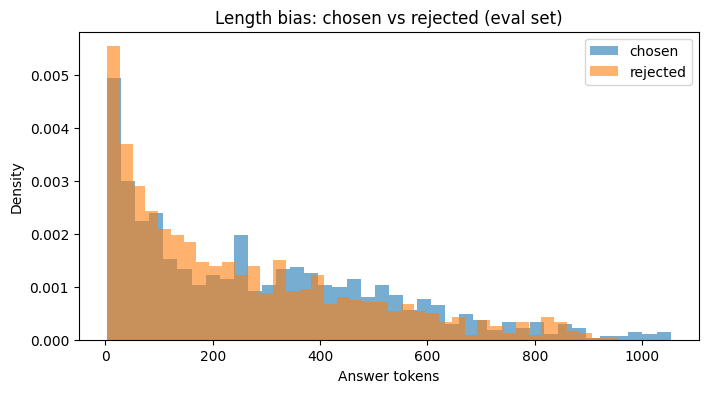

Saved: outputs/figures/fig1_length_bias.png


In [22]:
import os, pandas as pd, matplotlib.pyplot as plt

csv_path = "outputs/orpo_per_example_structured_n1000.csv"
if not os.path.exists(csv_path):
    csv_path = "/content/drive/MyDrive/CS555_DPO_Project/outputs/orpo_per_example_structured_n1000.csv"

df = pd.read_csv(csv_path)
os.makedirs("outputs/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["chosen_tokens"], bins=40, alpha=0.6, label="chosen", density=True)
ax.hist(df["rejected_tokens"], bins=40, alpha=0.6, label="rejected", density=True)
ax.set_xlabel("Answer tokens")
ax.set_ylabel("Density")
ax.set_title("Length bias: chosen vs rejected (eval set)")
ax.legend()
fig.savefig("outputs/figures/fig1_length_bias.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/fig1_length_bias.png")

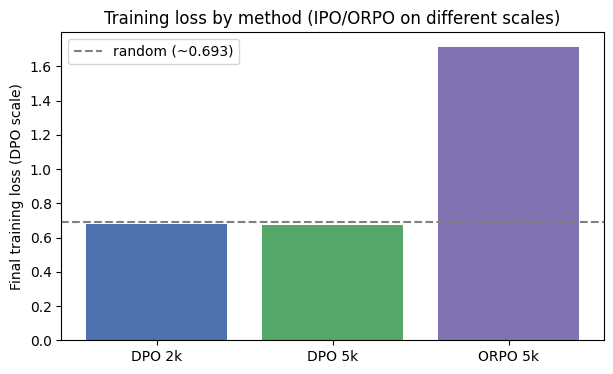

Saved: outputs/figures/fig2_train_loss.png
Note: IPO loss ~25 is ORPO/IPO objective scale, not plotted here.


In [24]:
# [RESULTS — completed] F2) Training loss comparison (bar chart — logged final losses)
import matplotlib.pyplot as plt

runs = [
    ("DPO 2k", 0.6814),
    ("DPO 5k", 0.6722),
    ("IPO 5k", 24.878),   # different scale — annotate separately
]
if os.path.exists(os.path.join(ORPO_OUTPUT_DIR if "ORPO_OUTPUT_DIR" in globals() else "outputs/dpo_lora_orpo5k_highmarg", "orpo_train_meta.json")):
    with open(os.path.join(ORPO_OUTPUT_DIR if "ORPO_OUTPUT_DIR" in globals() else "outputs/dpo_lora_orpo5k_highmarg", "orpo_train_meta.json")) as f:
        runs.append(("ORPO 5k", json.load(f)["final_train_loss"]))

dpo_runs = [(n, v) for n, v in runs if v < 2]
labels, vals = zip(*dpo_runs) if dpo_runs else ([], [])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, vals, color=["#4c72b0", "#55a868", "#8172b2", "#c44e52"][:len(vals)])
ax.axhline(-math.log(0.5), color="gray", ls="--", label="random (~0.693)")
ax.set_ylabel("Final training loss (DPO scale)")
ax.set_title("Training loss by method (IPO/ORPO on different scales)")
ax.legend()
fig.savefig("outputs/figures/fig2_train_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/fig2_train_loss.png")
print("Note: IPO loss ~25 is ORPO/IPO objective scale, not plotted here.")

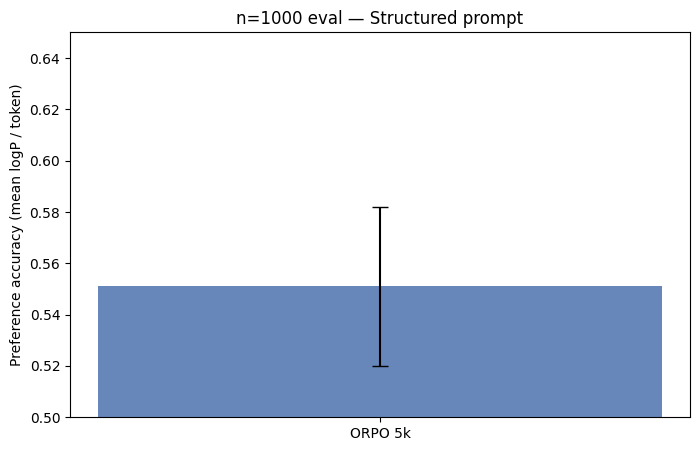

Saved: outputs/figures/fig3_prefacc_n1000.png


In [25]:
# [RESULTS — completed] F3) Headline bar chart — per-token PrefAcc @ n=1000 with 95% CI
import matplotlib.pyplot as plt
import math

paths = [
    ("outputs/baseline_metrics_structured_n1000.json", "Base"),
    ("outputs/dpo_metrics_train5k_structured_n1000.json", "DPO 5k"),
    ("outputs/ipo5k_metrics_structured_n1000.json", "IPO 5k"),
    ("outputs/orpo_metrics_structured_n1000.json", "ORPO 5k"),
]
labels, means, errs = [], [], []
for path, lab in paths:
    if not os.path.exists(path):
        continue
    with open(path) as f:
        d = json.load(f)
    n = int(d.get("n_valid", 1000))
    p = float(d.get("preference_accuracy_mean", 0))
    se = math.sqrt(max(p * (1 - p) / n, 1e-12))
    labels.append(lab)
    means.append(p)
    errs.append(1.96 * se)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, means, yerr=errs, capsize=6, color="#4c72b0", alpha=0.85)
ax.set_ylabel("Preference accuracy (mean logP / token)")
ax.set_title("n=1000 eval — Structured prompt")
ax.set_ylim(0.5, 0.65)
fig.savefig("outputs/figures/fig3_prefacc_n1000.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/fig3_prefacc_n1000.png")

In [26]:
# [OPTIONAL - Phase A] Wilcoxon signed-rank on per-example margins (n=1000)
# Requires CSVs from B1 + B2 (+ C4 for ORPO). pip install scipy if needed.

try:
    from scipy.stats import wilcoxon
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scipy"])
    from scipy.stats import wilcoxon

import pandas as pd

def _load_margin(path):
    return pd.read_csv(path)["margin_mean_per_token"].values

pairs = [
    ("outputs/baseline_per_example_structured_n1000.csv",
     "outputs/dpo_per_example_train5k_structured_n1000.csv", "Base vs DPO 5k"),
    ("outputs/baseline_per_example_structured_n1000.csv",
     "outputs/ipo5k_per_example_structured_n1000.csv", "Base vs IPO 5k"),
    ("outputs/baseline_per_example_structured_n1000.csv",
     "outputs/orpo_per_example_structured_n1000.csv", "Base vs ORPO 5k"),
]
for a, b, name in pairs:
    if os.path.exists(a) and os.path.exists(b):
        x, y = _load_margin(a), _load_margin(b)
        stat, p = wilcoxon(x, y)
        print(f"{name}: Wilcoxon stat={stat:.2f}, p={p:.4g}")
    else:
        print(f"Skip {name} — missing CSV")

Skip Base vs DPO 5k — missing CSV
Skip Base vs IPO 5k — missing CSV
Skip Base vs ORPO 5k — missing CSV
